## **1. Data Understanding & Data Quality Assessment**

1. Importing Libraries

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


2. Uploading Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving E-commerce Customer Behavior.csv to E-commerce Customer Behavior.csv


In [ ]:
df = pd.read_csv(next(iter(uploaded)))

print("Dataset loaded successfully!")

Dataset loaded successfully!


3. Checking Dataset

In [ ]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [ ]:
df.shape

(350, 11)

In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

4. Basic Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


5. Statistical Summary

In [ ]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


6. Missing Values

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


7. Duplicate Check

In [ ]:
df.duplicated().sum()

np.int64(0)

## **2. Understand Categorical Data**

8. Unique Values

In [ ]:
# Check unique values in categorical columns

categorical_columns = [
    'Gender',
    'City',
    'Membership Type',
    'Discount Applied',
    'Satisfaction Level'
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Gender
['Female' 'Male']

City
['New York' 'Los Angeles' 'Chicago' 'San Francisco' 'Miami' 'Houston']

Membership Type
['Gold' 'Silver' 'Bronze']

Discount Applied
[ True False]

Satisfaction Level
['Satisfied' 'Neutral' 'Unsatisfied' nan]


9. Frequency Counts

In [ ]:
for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False))


Gender
Gender
Female    175
Male      175
Name: count, dtype: int64

City
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

Membership Type
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

Discount Applied
Discount Applied
True     175
False    175
Name: count, dtype: int64

Satisfaction Level
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
NaN              2
Name: count, dtype: int64


10. Investigate the 2 missing values

In [ ]:
# Display rows with missing Satisfaction Level

df[df['Satisfaction Level'].isna()]

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
71,172,Female,37,Houston,Bronze,420.8,7,3.1,False,21,NaN
143,244,Female,37,Houston,Bronze,430.8,7,3.4,False,23,NaN


In [ ]:
# Check the characteristics of customers with missing satisfaction

missing_satisfaction = df[df['Satisfaction Level'].isna()]

missing_satisfaction

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
71,172,Female,37,Houston,Bronze,420.8,7,3.1,False,21,NaN
143,244,Female,37,Houston,Bronze,430.8,7,3.4,False,23,NaN


In [ ]:
# Compare missing-satisfaction customers with the overall dataset

missing_satisfaction[['Gender',
                      'Age',
                      'City',
                      'Membership Type',
                      'Total Spend',
                      'Items Purchased',
                      'Average Rating',
                      'Discount Applied',
                      'Days Since Last Purchase']]

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase
71,Female,37,Houston,Bronze,420.8,7,3.1,False,21
143,Female,37,Houston,Bronze,430.8,7,3.4,False,23


11. Handling Missing Values

In [ ]:
# Check missing values before treatment

print("Missing values before treatment:")
print(df.isnull().sum())

Missing values before treatment:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


12. create a cleaned dataset specifically for satisfaction analysis

In [ ]:
# Create dataset for analyses involving Satisfaction Level

df_satisfaction = df.dropna(subset=['Satisfaction Level']).copy()

print("Original dataset shape:", df.shape)
print("Satisfaction analysis dataset shape:", df_satisfaction.shape)

Original dataset shape: (350, 11)
Satisfaction analysis dataset shape: (348, 11)


13. Verify Data Quality Again

In [ ]:
# Final data quality check

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

Duplicate rows:
0


# **3. EDA**

Part 1: Customer Profile Analysis

CUSTOMER AGE ANALYSIS

1. AGE STATISTICS
----------------------------------------
count    350.000000
mean      33.597143
std        4.870882
min       26.000000
25%       30.000000
50%       32.500000
75%       37.000000
max       43.000000
Name: Age, dtype: float64


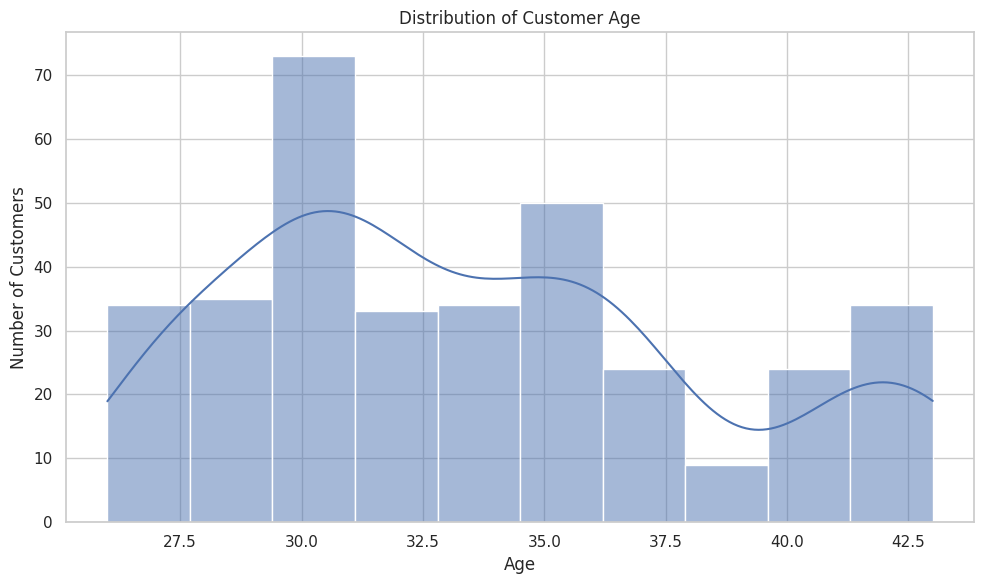


2. CUSTOMER COUNT BY AGE GROUP
----------------------------------------
Age Group
26-30    117
31-35    117
36-40     58
41-45     58
Name: count, dtype: int64

3. CUSTOMER PERCENTAGE BY AGE GROUP
----------------------------------------
Age Group
26-30    33.43
31-35    33.43
36-40    16.57
41-45    16.57
Name: proportion, dtype: float64


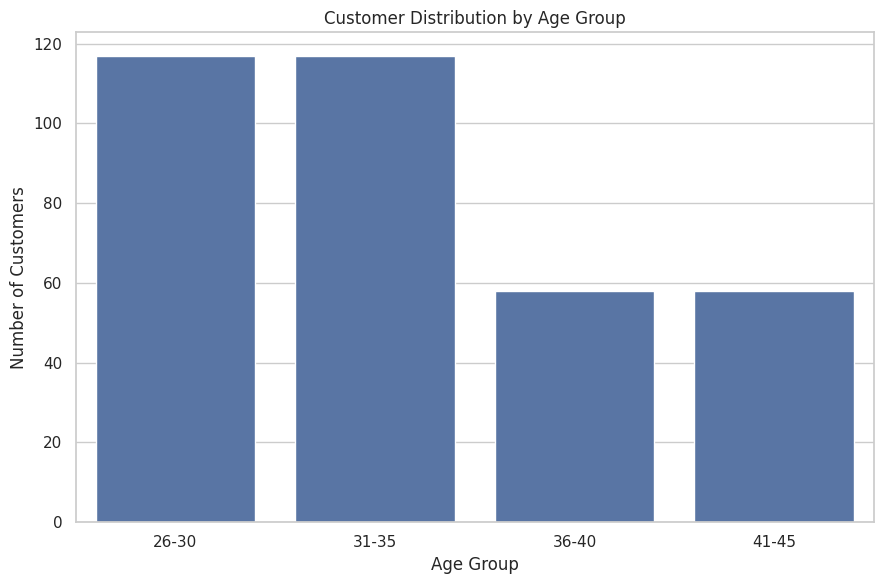


4. SPENDING BY AGE GROUP
----------------------------------------
           count     mean   median       sum
Age Group                                   
26-30        117  1176.17  1200.80  137611.7
31-35        117   875.12   810.90  102388.6
36-40         58   463.62   440.90   26890.1
41-45         58   499.88   500.75   28993.2


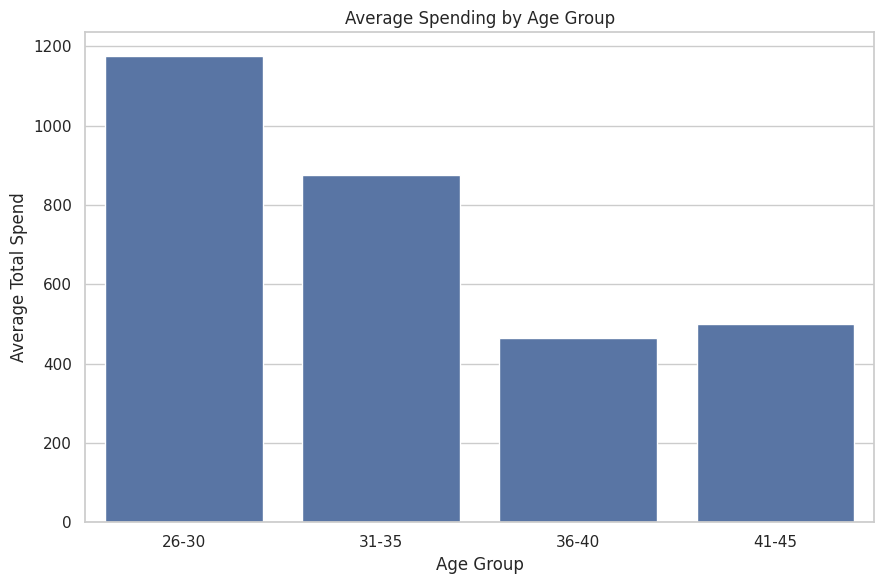

In [44]:
# ============================================================
# EDA PART 1 — CUSTOMER AGE ANALYSIS
# ============================================================

print("=" * 60)
print("CUSTOMER AGE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Basic Age Statistics
# ------------------------------------------------------------

print("\n1. AGE STATISTICS")
print("-" * 40)

age_stats = df['Age'].describe()
print(age_stats)


# ------------------------------------------------------------
# 2. Age Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Age',
    bins=10,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Create Age Groups
# ------------------------------------------------------------

age_bins = [25, 30, 35, 40, 45]
age_labels = ['26-30', '31-35', '36-40', '41-45']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

print("\n2. CUSTOMER COUNT BY AGE GROUP")
print("-" * 40)

age_group_count = (
    df['Age Group']
    .value_counts()
    .sort_index()
)

print(age_group_count)


# ------------------------------------------------------------
# 4. Age Group Percentage
# ------------------------------------------------------------

print("\n3. CUSTOMER PERCENTAGE BY AGE GROUP")
print("-" * 40)

age_group_percentage = (
    df['Age Group']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(age_group_percentage)


# ------------------------------------------------------------
# 5. Age Group Distribution Chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='Age Group'
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Age Group vs Spending
# ------------------------------------------------------------

print("\n4. SPENDING BY AGE GROUP")
print("-" * 40)

age_spending = (
    df.groupby('Age Group', observed=True)['Total Spend']
    .agg(['count', 'mean', 'median', 'sum'])
    .round(2)
)

print(age_spending)


# ------------------------------------------------------------
# 7. Average Spending by Age Group
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x='Age Group',
    y='Total Spend',
    estimator='mean',
    errorbar=None
)

plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Total Spend')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Quick Summary
# ------------------------------------------------------------

highest_avg_spend_group = age_spending['mean'].idxmax()
highest_avg_spend = age_spending['mean'].max()

largest_age_group = age_group_count.idxmax()
largest_age_group_count = age_group_count.max()

### Age Analysis — Key Insights

- Customers aged 26–30 and 31–35 form the largest customer groups, with 117 customers each.
- Customers aged 26–35 account for approximately 66.86% of the total customer base.
- The 26–30 age group has the highest average total spending at approximately $1,176.17.
- Average spending decreases substantially across the older age groups in this dataset.
- These findings describe patterns within the dataset and should not be interpreted as evidence of causation.

Part 2 — Gender Analysis

CUSTOMER COUNT BY GENDER
Gender
Female    175
Male      175
Name: count, dtype: int64


/tmp/ipykernel_5430/3057664728.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='coolwarm')


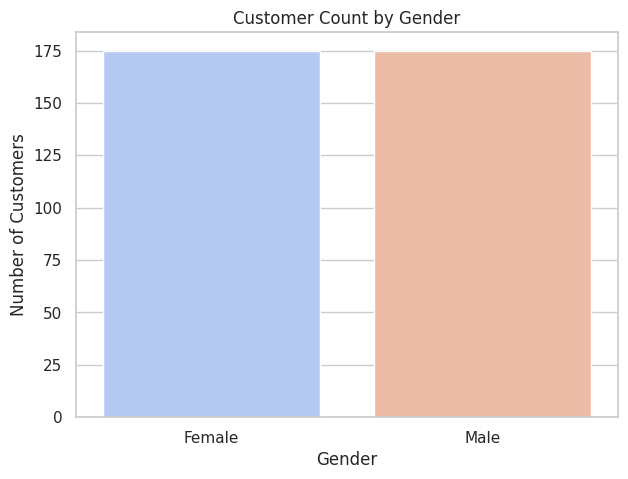

In [ ]:
# 1. Customer Count by Gender
print('=' * 60)
print('CUSTOMER COUNT BY GENDER')
print('=' * 60)
gender_counts = df['Gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='coolwarm')
plt.title('Customer Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()


TOTAL SPENDING BY GENDER
Gender
Male      172713.6
Female    123170.0
Name: Total Spend, dtype: float64


/tmp/ipykernel_5430/454440612.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_total_spend.index, y=gender_total_spend.values, palette='magma')


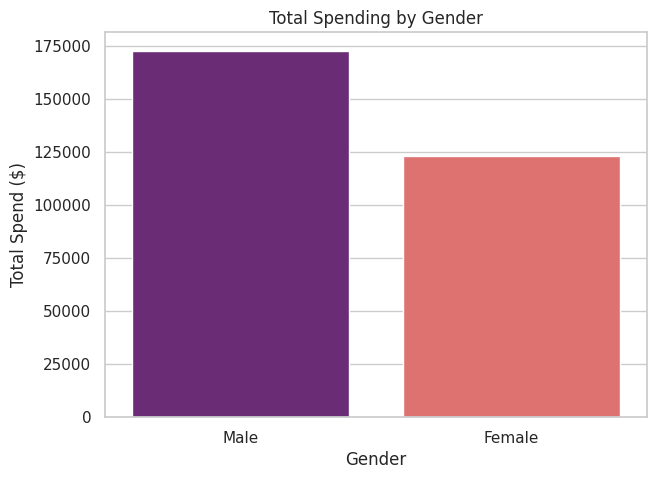

In [ ]:
# 2. Total Spending by Gender
print('\n' + '=' * 60)
print('TOTAL SPENDING BY GENDER')
print('=' * 60)
gender_total_spend = df.groupby('Gender')['Total Spend'].sum().sort_values(ascending=False)
print(gender_total_spend)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_total_spend.index, y=gender_total_spend.values, palette='magma')
plt.title('Total Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spend ($)')
plt.show()


AVERAGE ITEMS PURCHASED BY GENDER
Gender
Male      14.44
Female    10.76
Name: Items Purchased, dtype: float64


/tmp/ipykernel_5430/3414173966.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_avg_items.index, y=gender_avg_items.values, palette='viridis')


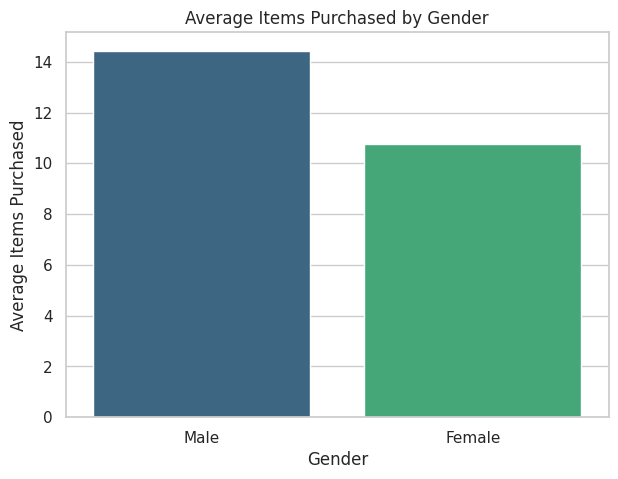

In [ ]:
# 3. Average Items Purchased by Gender
print('\n' + '=' * 60)
print('AVERAGE ITEMS PURCHASED BY GENDER')
print('=' * 60)
gender_avg_items = df.groupby('Gender')['Items Purchased'].mean().sort_values(ascending=False)
print(gender_avg_items)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_avg_items.index, y=gender_avg_items.values, palette='viridis')
plt.title('Average Items Purchased by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Items Purchased')
plt.show()


AVERAGE RATING BY GENDER
Gender
Male      4.306857
Female    3.731429
Name: Average Rating, dtype: float64


/tmp/ipykernel_5430/1588129753.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_avg_rating.index, y=gender_avg_rating.values, palette='plasma')


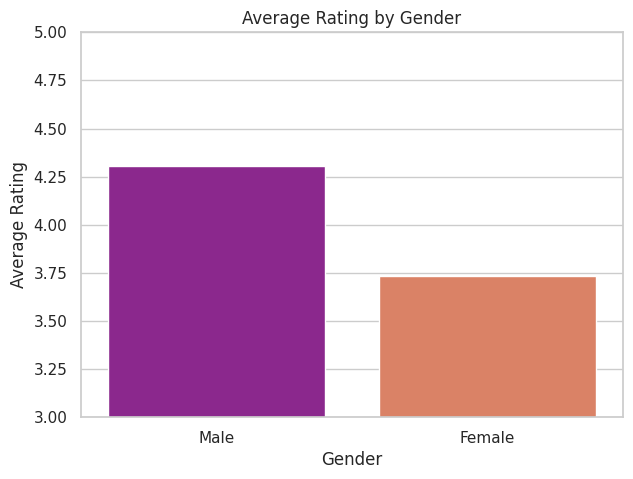

In [ ]:
# 4. Average Rating by Gender
print('\n' + '=' * 60)
print('AVERAGE RATING BY GENDER')
print('=' * 60)
gender_avg_rating = df.groupby('Gender')['Average Rating'].mean().sort_values(ascending=False)
print(gender_avg_rating)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_avg_rating.index, y=gender_avg_rating.values, palette='plasma')
plt.title('Average Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Rating')
plt.ylim(3.0, 5.0) # Set a reasonable y-limit for ratings
plt.show()


DISCOUNT USAGE BY GENDER
Discount Applied  False  True 
Gender                        
Female            33.14  66.86
Male              66.86  33.14


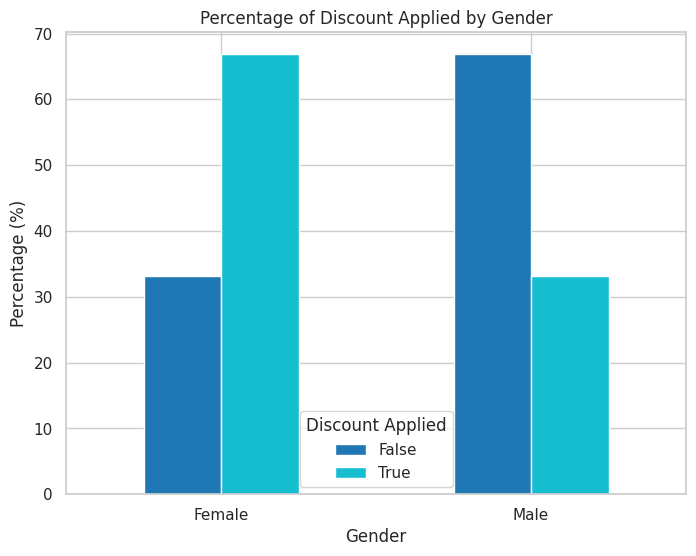

In [ ]:
# 5. Discount Usage by Gender
print('\n' + '=' * 60)
print('DISCOUNT USAGE BY GENDER')
print('=' * 60)
gender_discount_usage = df.groupby('Gender')['Discount Applied'].value_counts(normalize=True).unstack().mul(100).round(2)
print(gender_discount_usage)

gender_discount_usage.plot(kind='bar', figsize=(8, 6), colormap='tab10')
plt.title('Percentage of Discount Applied by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Discount Applied')
plt.show()

### Gender Analysis — Key Insights

- The dataset contains an equal number of Male and Female customers, with 175 customers in each group.
- Male customers show higher total spending than Female customers.
- Male customers also purchase more items on average.
- The average customer rating is higher for Male customers than Female customers in this dataset.
- Discount usage differs noticeably between the two groups, with Female customers showing a higher proportion of discount usage.
- These observations describe patterns within this dataset and should not be interpreted as evidence that gender causes differences in spending, purchasing, ratings, or discount usage.

Part 3 — City Analysis

CITY ANALYSIS

1. CUSTOMER COUNT BY CITY
----------------------------------------
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

2. CUSTOMER PERCENTAGE BY CITY
----------------------------------------
City
New York         16.86
Los Angeles      16.86
Chicago          16.57
San Francisco    16.57
Miami            16.57
Houston          16.57
Name: proportion, dtype: float64


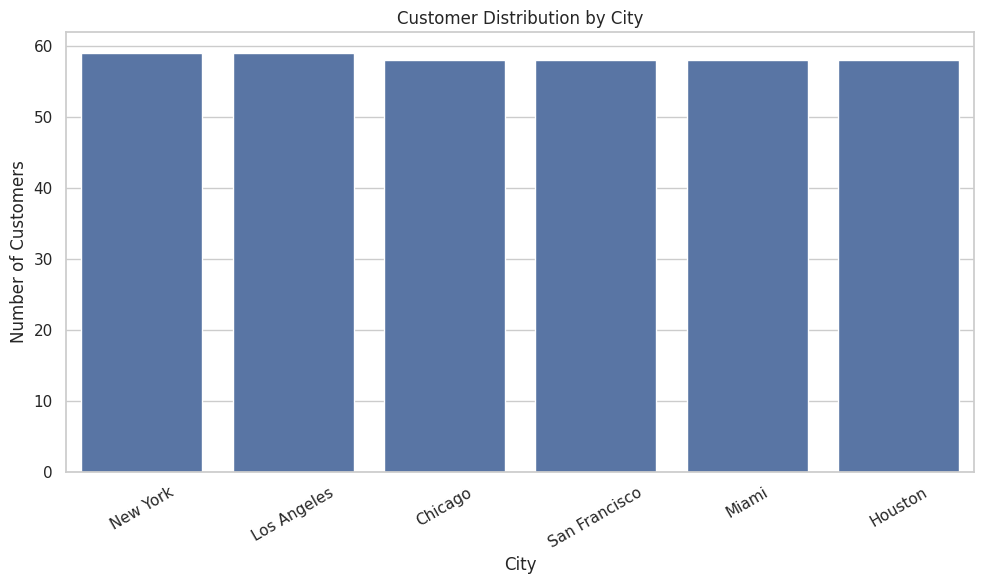


3. CITY-WISE CUSTOMER BEHAVIOR
----------------------------------------
               Customers  Average_Age  Average_Spend  Median_Spend  \
City                                                                 
San Francisco         58        29.12        1459.77       1470.50   
New York              59        30.71        1165.04       1160.60   
Los Angeles           59        34.12         805.49        800.90   
Miami                 58        28.95         690.39        690.60   
Chicago               58        42.02         499.88        500.75   
Houston               58        36.71         446.89        440.90   

               Total_Spend  Average_Items  Average_Rating  Average_Recency  
City                                                                        
San Francisco      84666.8          20.00            4.81            11.17  
New York           68737.1          15.27            4.54            24.59  
Los Angeles        47524.0          11.68            4.17 

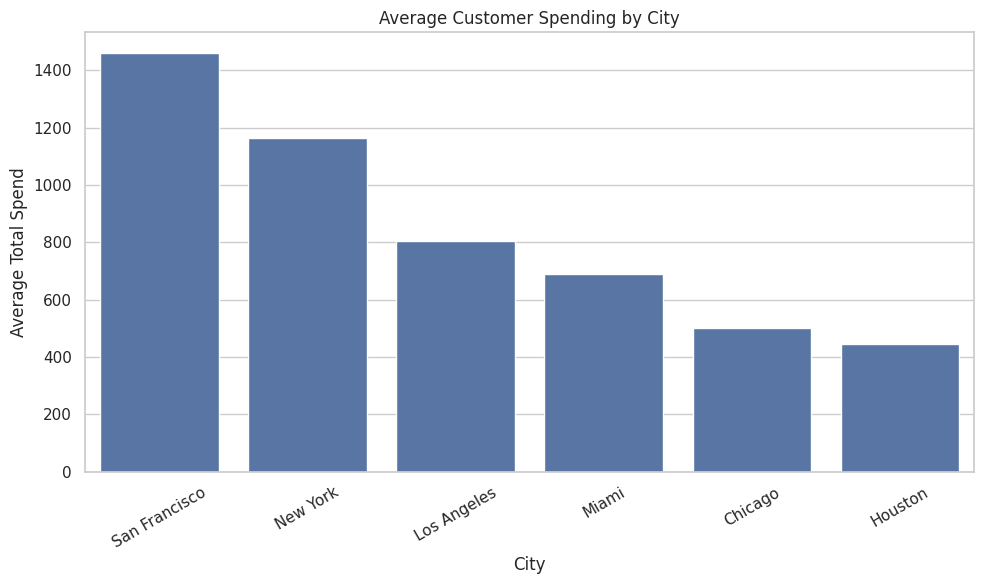

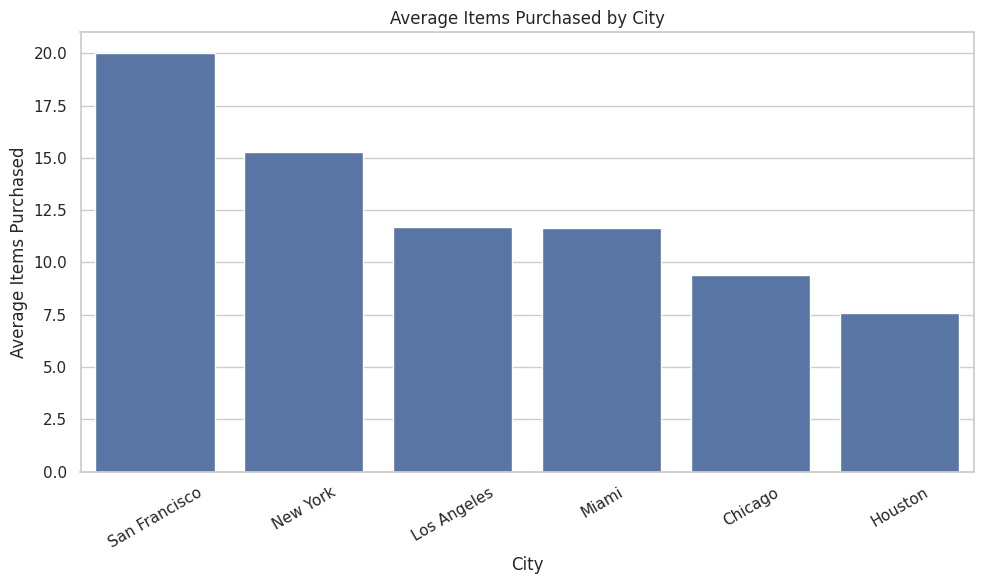

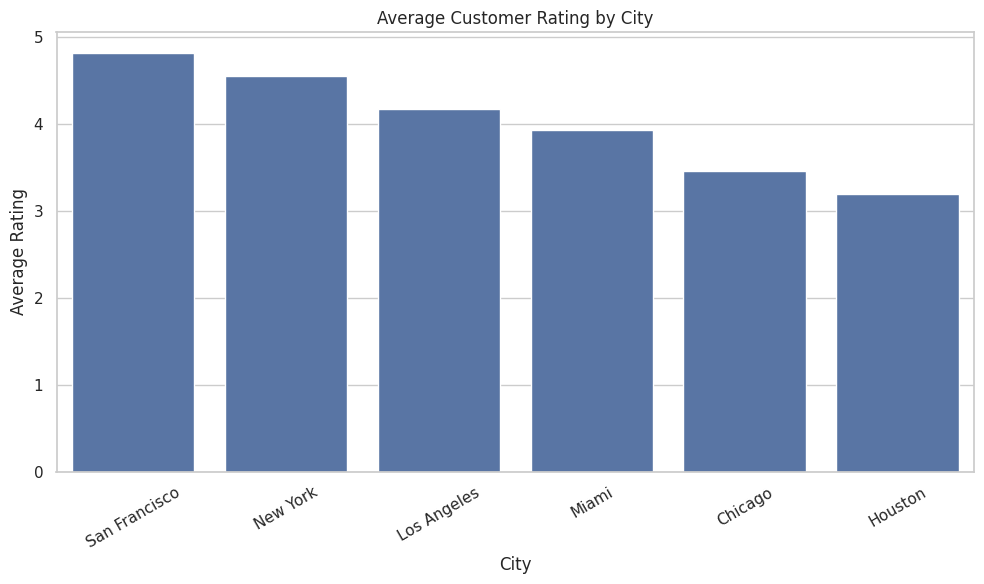


4. DISCOUNT USAGE (%) BY CITY
----------------------------------------
Discount Applied  False  True 
City                          
Chicago             0.0  100.0
Houston           100.0    0.0
Los Angeles       100.0    0.0
Miami               0.0  100.0
New York            0.0  100.0
San Francisco     100.0    0.0


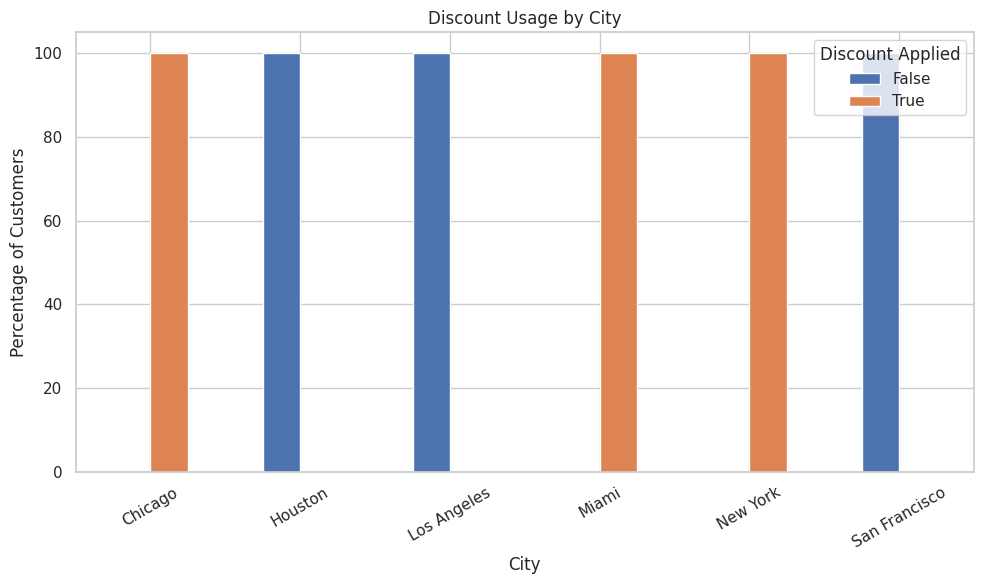


5. AVERAGE DAYS SINCE LAST PURCHASE BY CITY
----------------------------------------
City
San Francisco    11.17
Los Angeles      15.27
Houston          22.76
New York         24.59
Chicago          40.47
Miami            45.50
Name: Days Since Last Purchase, dtype: float64


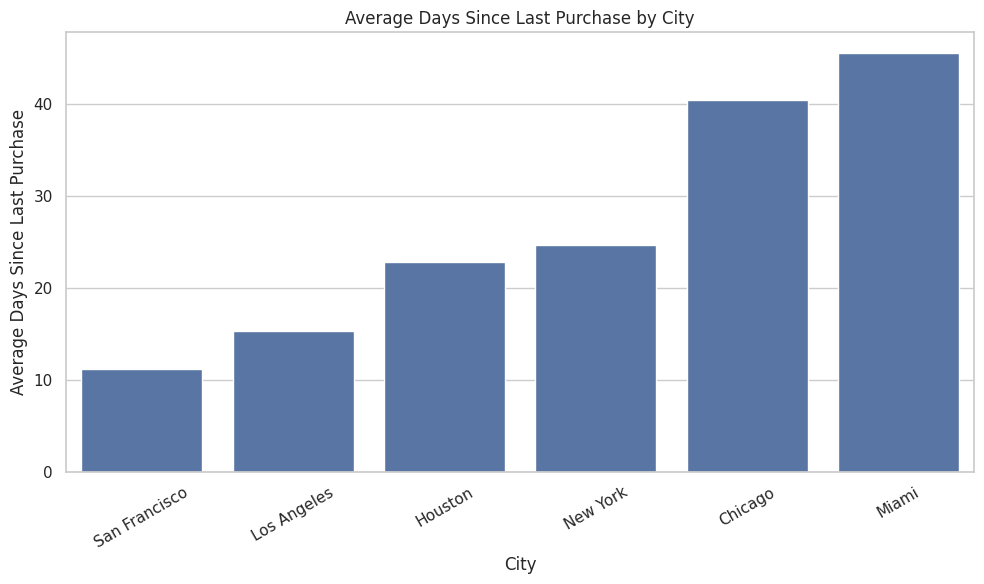

In [45]:
# ============================================================
# EDA PART 3 — CITY ANALYSIS
# ============================================================

print("=" * 60)
print("CITY ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Customer Count by City
# ------------------------------------------------------------

city_count = (
    df['City']
    .value_counts()
    .sort_values(ascending=False)
)

print("\n1. CUSTOMER COUNT BY CITY")
print("-" * 40)
print(city_count)


# ------------------------------------------------------------
# 2. Customer Percentage by City
# ------------------------------------------------------------

city_percentage = (
    df['City']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("\n2. CUSTOMER PERCENTAGE BY CITY")
print("-" * 40)
print(city_percentage)


# ------------------------------------------------------------
# 3. Customer Distribution by City
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_count.index,
    y=city_count.values
)

plt.title('Customer Distribution by City')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. City-wise Customer Behavior
# ------------------------------------------------------------

city_behavior = (
    df.groupby('City')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Age=('Age', 'mean'),
        Average_Spend=('Total Spend', 'mean'),
        Median_Spend=('Total Spend', 'median'),
        Total_Spend=('Total Spend', 'sum'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .round(2)
    .sort_values('Average_Spend', ascending=False)
)

print("\n3. CITY-WISE CUSTOMER BEHAVIOR")
print("-" * 40)
print(city_behavior)


# ------------------------------------------------------------
# 5. Average Spending by City
# ------------------------------------------------------------

city_avg_spend = (
    df.groupby('City')['Total Spend']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_avg_spend.index,
    y=city_avg_spend.values
)

plt.title('Average Customer Spending by City')
plt.xlabel('City')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Average Items Purchased by City
# ------------------------------------------------------------

city_avg_items = (
    df.groupby('City')['Items Purchased']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_avg_items.index,
    y=city_avg_items.values
)

plt.title('Average Items Purchased by City')
plt.xlabel('City')
plt.ylabel('Average Items Purchased')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Average Rating by City
# ------------------------------------------------------------

city_avg_rating = (
    df.groupby('City')['Average Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_avg_rating.index,
    y=city_avg_rating.values
)

plt.title('Average Customer Rating by City')
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Discount Usage by City
# ------------------------------------------------------------

discount_city = (
    pd.crosstab(
        df['City'],
        df['Discount Applied'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print("\n4. DISCOUNT USAGE (%) BY CITY")
print("-" * 40)
print(discount_city)


# ------------------------------------------------------------
# 9. Discount Usage Visualization
# ------------------------------------------------------------

discount_city.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Discount Usage by City')
plt.xlabel('City')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=30)
plt.legend(title='Discount Applied')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Recency Analysis by City
# ------------------------------------------------------------

city_recency = (
    df.groupby('City')['Days Since Last Purchase']
    .mean()
    .sort_values()
)

print("\n5. AVERAGE DAYS SINCE LAST PURCHASE BY CITY")
print("-" * 40)
print(city_recency.round(2))


plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_recency.index,
    y=city_recency.values
)

plt.title('Average Days Since Last Purchase by City')
plt.xlabel('City')
plt.ylabel('Average Days Since Last Purchase')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### City Analysis — Key Insights

- Customer distribution is relatively balanced across the six cities, with each city representing approximately 16.57%–16.86% of the dataset.
- San Francisco has the highest average customer spending ($1,459.77) and the highest average number of items purchased (20.00).
- New York has the second-highest average spending at approximately $1,165.04.
- San Francisco also has the highest average customer rating (4.81) and the lowest average days since last purchase (11.17 days).
- Houston has the lowest average spending ($446.89) and the lowest average number of items purchased (7.50).
- The city-level results show noticeable differences in spending, purchasing activity, ratings and purchase recency.
- Discount usage is completely aligned with city in this dataset: some cities have 100% discount usage while others have 0%. Therefore, the independent effect of discounts on spending cannot be isolated from city using a simple comparison.
- These observations describe associations within this dataset and should not be interpreted as causal relationships.

Part 4 — Membership Analysis

MEMBERSHIP TYPE ANALYSIS

1. CUSTOMER COUNT BY MEMBERSHIP TYPE
----------------------------------------
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

2. CUSTOMER PERCENTAGE BY MEMBERSHIP TYPE
----------------------------------------
Membership Type
Gold      33.43
Silver    33.43
Bronze    33.14
Name: proportion, dtype: float64


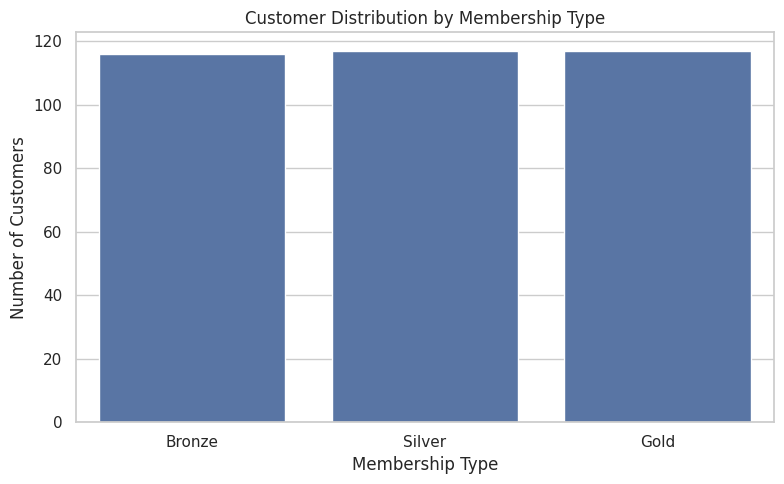


3. MEMBERSHIP-WISE CUSTOMER BEHAVIOR
----------------------------------------
                 Customers  Average_Age  Average_Spend  Median_Spend  \
Membership Type                                                        
Bronze                 116        39.36         473.39        475.25   
Silver                 117        31.56         748.43        770.20   
Gold                   117        29.92        1311.14       1210.60   

                 Total_Spend  Average_Items  Average_Rating  Average_Recency  
Membership Type                                                               
Bronze               54913.1           8.49            3.32            31.61  
Silver               87566.6          11.66            4.05            30.26  
Gold                153403.9          17.62            4.68            17.94  


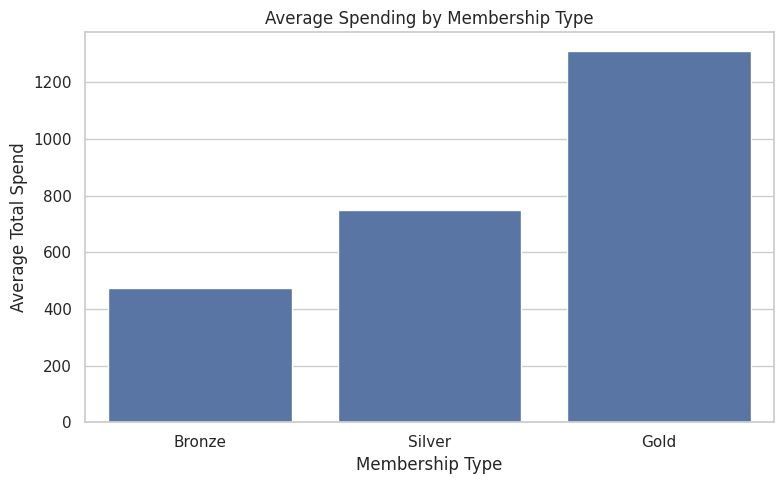

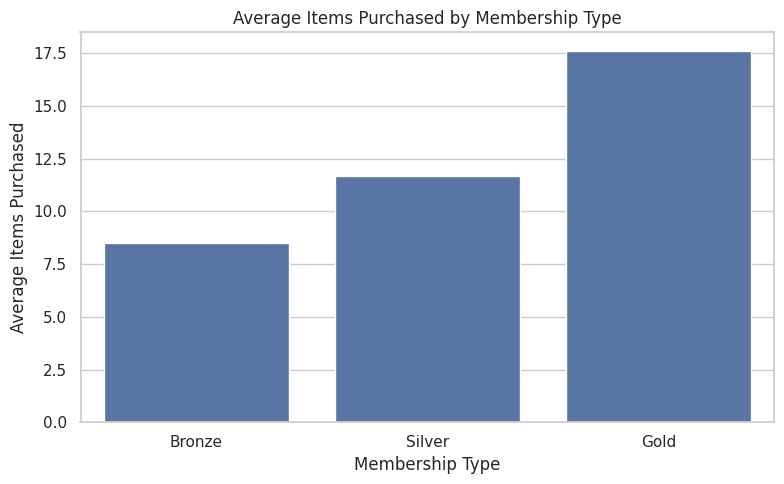

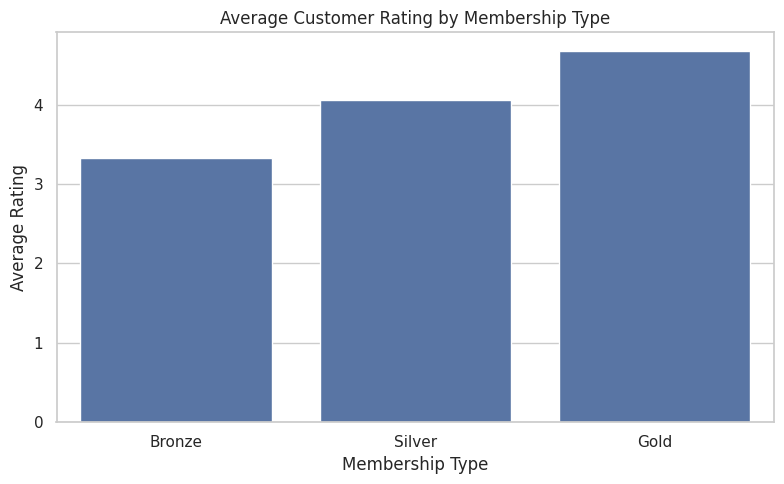


4. AVERAGE DAYS SINCE LAST PURCHASE
----------------------------------------
Membership Type
Bronze    31.61
Silver    30.26
Gold      17.94
Name: Days Since Last Purchase, dtype: float64


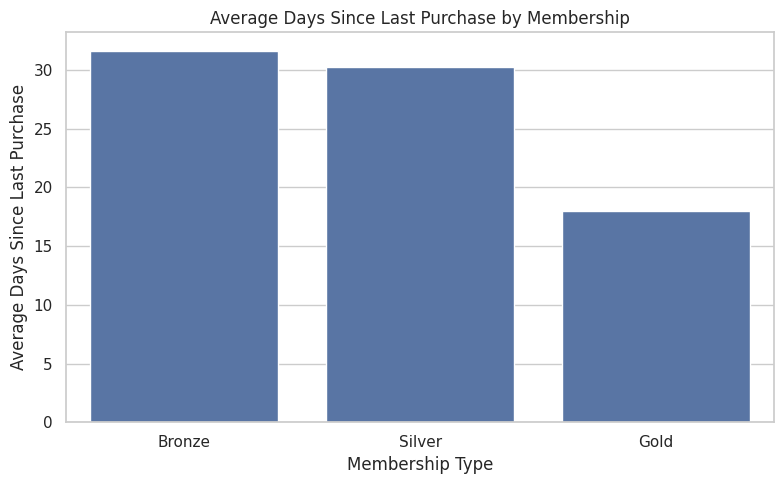


5. DISCOUNT USAGE (%) BY MEMBERSHIP
----------------------------------------
Discount Applied  False  True 
Membership Type               
Bronze            50.00  50.00
Silver            50.43  49.57
Gold              49.57  50.43


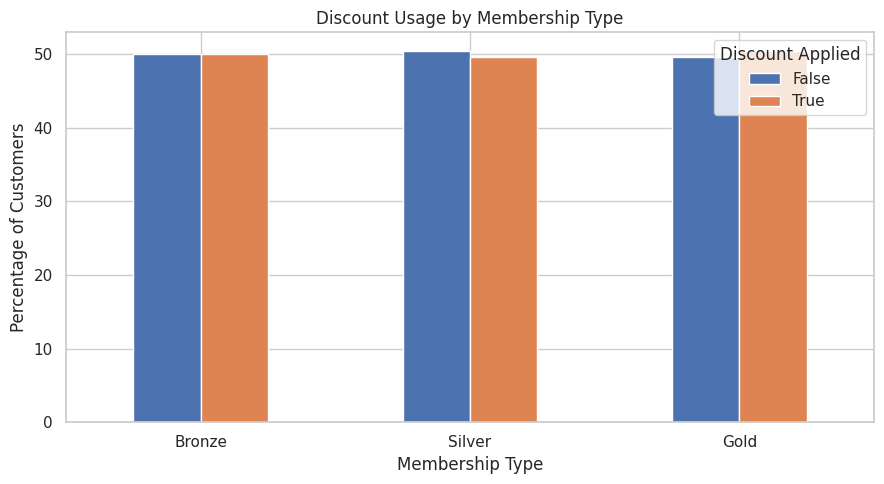


6. SATISFACTION DISTRIBUTION (%) BY MEMBERSHIP
----------------------------------------
Satisfaction Level  Neutral  Satisfied  Unsatisfied
Membership Type                                    
Bronze                49.12       0.00        50.88
Silver                43.59       6.84        49.57
Gold                   0.00     100.00         0.00


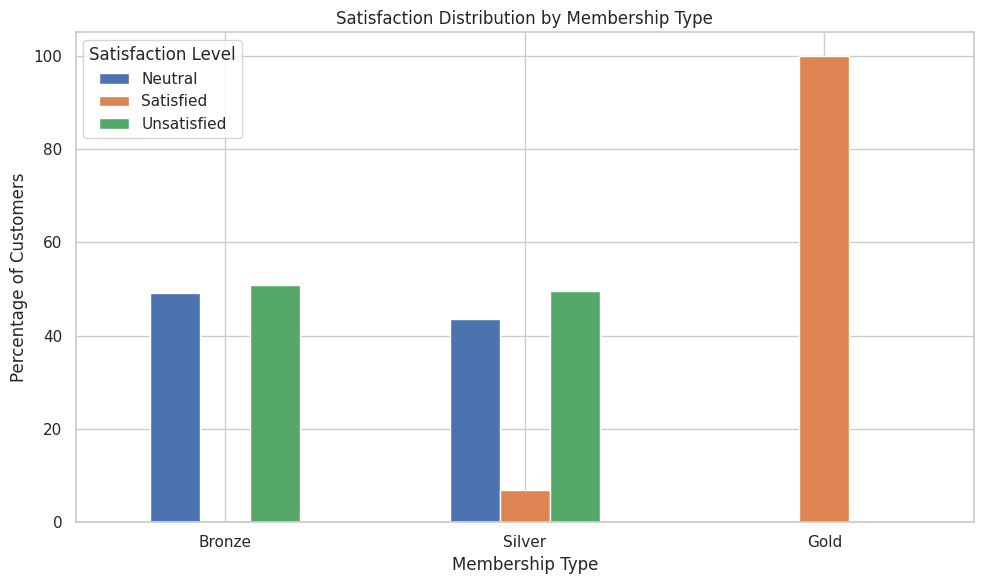


Membership analysis completed successfully.


In [46]:
# ============================================================
# EDA PART 4 — MEMBERSHIP TYPE ANALYSIS
# ============================================================

print("=" * 60)
print("MEMBERSHIP TYPE ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Customer Count by Membership Type
# ------------------------------------------------------------

membership_count = (
    df['Membership Type']
    .value_counts()
)

print("\n1. CUSTOMER COUNT BY MEMBERSHIP TYPE")
print("-" * 40)
print(membership_count)


# ------------------------------------------------------------
# 2. Customer Percentage
# ------------------------------------------------------------

membership_percentage = (
    df['Membership Type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n2. CUSTOMER PERCENTAGE BY MEMBERSHIP TYPE")
print("-" * 40)
print(membership_percentage)


# ------------------------------------------------------------
# 3. Membership Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Membership Type',
    order=['Bronze', 'Silver', 'Gold']
)

plt.title('Customer Distribution by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Membership-wise Customer Behavior
# ------------------------------------------------------------

membership_behavior = (
    df.groupby('Membership Type')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Age=('Age', 'mean'),
        Average_Spend=('Total Spend', 'mean'),
        Median_Spend=('Total Spend', 'median'),
        Total_Spend=('Total Spend', 'sum'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .round(2)
    .reindex(['Bronze', 'Silver', 'Gold'])
)

print("\n3. MEMBERSHIP-WISE CUSTOMER BEHAVIOR")
print("-" * 40)
print(membership_behavior)


# ------------------------------------------------------------
# 5. Average Spending by Membership
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Membership Type',
    y='Total Spend',
    order=['Bronze', 'Silver', 'Gold'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Spending by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Average Total Spend')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Average Items Purchased
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Membership Type',
    y='Items Purchased',
    order=['Bronze', 'Silver', 'Gold'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Items Purchased by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Average Items Purchased')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Average Rating
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Membership Type',
    y='Average Rating',
    order=['Bronze', 'Silver', 'Gold'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Customer Rating by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Purchase Recency
# ------------------------------------------------------------

membership_recency = (
    df.groupby('Membership Type')['Days Since Last Purchase']
    .mean()
    .reindex(['Bronze', 'Silver', 'Gold'])
    .round(2)
)

print("\n4. AVERAGE DAYS SINCE LAST PURCHASE")
print("-" * 40)
print(membership_recency)


plt.figure(figsize=(8, 5))

sns.barplot(
    x=membership_recency.index,
    y=membership_recency.values
)

plt.title('Average Days Since Last Purchase by Membership')
plt.xlabel('Membership Type')
plt.ylabel('Average Days Since Last Purchase')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Discount Usage by Membership
# ------------------------------------------------------------

discount_membership = (
    pd.crosstab(
        df['Membership Type'],
        df['Discount Applied'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .reindex(['Bronze', 'Silver', 'Gold'])
)

print("\n5. DISCOUNT USAGE (%) BY MEMBERSHIP")
print("-" * 40)
print(discount_membership)


discount_membership.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Discount Usage by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Discount Applied')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Satisfaction by Membership
# ------------------------------------------------------------

satisfaction_membership = (
    pd.crosstab(
        df['Membership Type'],
        df['Satisfaction Level'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .reindex(['Bronze', 'Silver', 'Gold'])
)

print("\n6. SATISFACTION DISTRIBUTION (%) BY MEMBERSHIP")
print("-" * 40)
print(satisfaction_membership)


satisfaction_membership.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Satisfaction Distribution by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Satisfaction Level')
plt.tight_layout()
plt.show()

print("\nMembership analysis completed successfully.")

### Membership Analysis — Key Insights

- The dataset contains an almost equal number of Bronze, Silver and Gold customers.
- Average spending increases across membership levels: Bronze ($473.39), Silver ($748.43) and Gold ($1,311.14).
- Gold customers purchase the highest average number of items (17.62), compared with Silver (11.66) and Bronze (8.49).
- Average customer rating also increases across membership levels, from 3.32 for Bronze to 4.68 for Gold.
- Gold customers have the lowest average days since last purchase (17.94 days), indicating more recent purchasing activity within this dataset.
- Discount usage is approximately 50% for all three membership groups, showing little difference in discount application by membership type.
- Satisfaction Level shows a very strong association with membership: 100% of Gold customers are classified as Satisfied, while Bronze customers are classified as Neutral or Unsatisfied.
- The observed relationships describe patterns in the dataset and do not establish that membership type causes differences in spending, satisfaction or purchasing behavior.

Part 5 — Spending Behavior Analysis

SPENDING BEHAVIOR & CORRELATION ANALYSIS

1. TOTAL SPENDING STATISTICS
---------------------------------------------
count     350.00
mean      845.38
std       362.06
min       410.80
25%       502.00
50%       775.20
75%      1160.60
max      1520.10
Name: Total Spend, dtype: float64


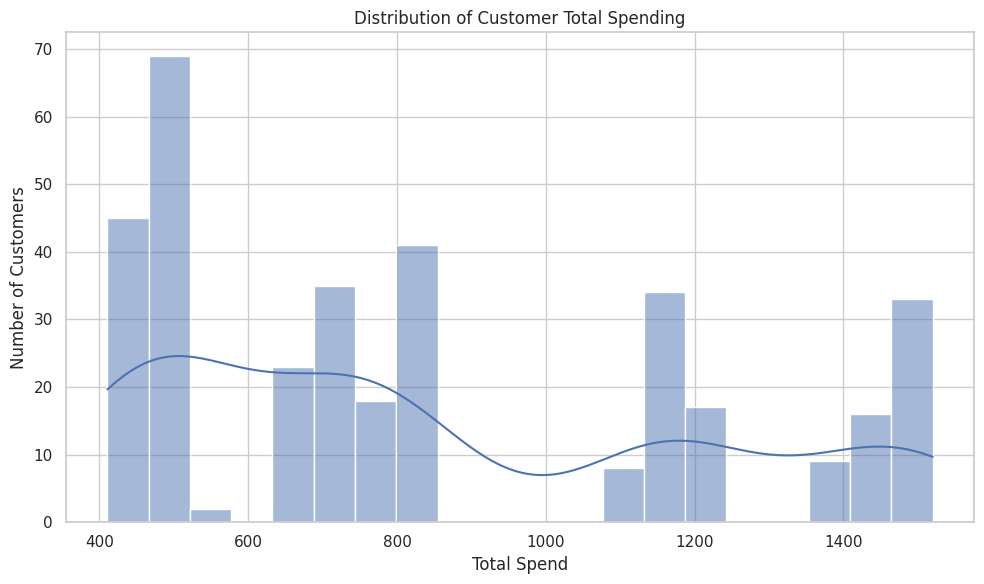

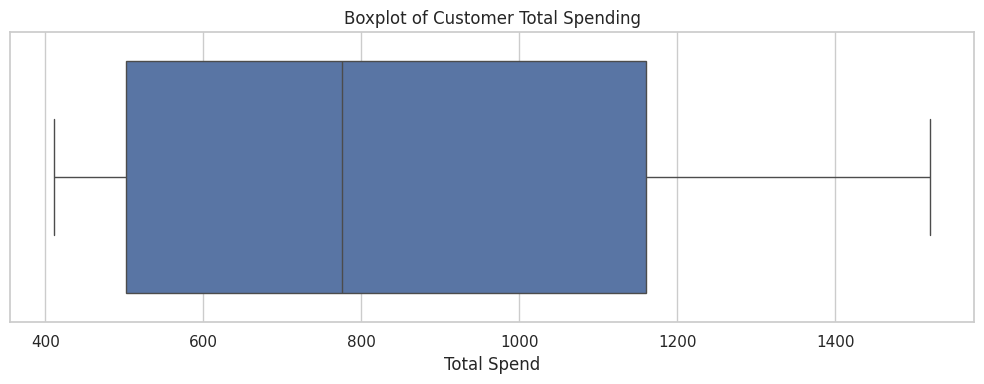

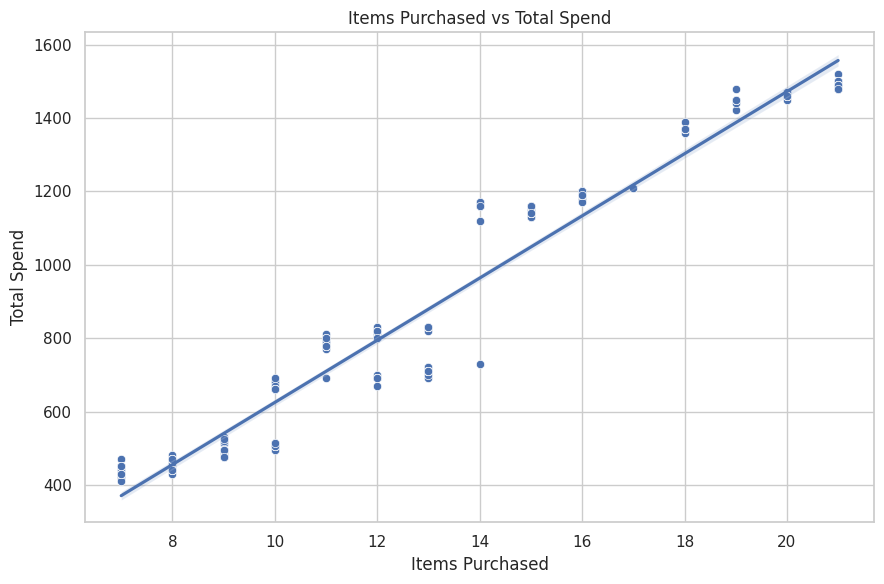


2. CORRELATION: ITEMS PURCHASED vs TOTAL SPEND
---------------------------------------------
Correlation coefficient: 0.972


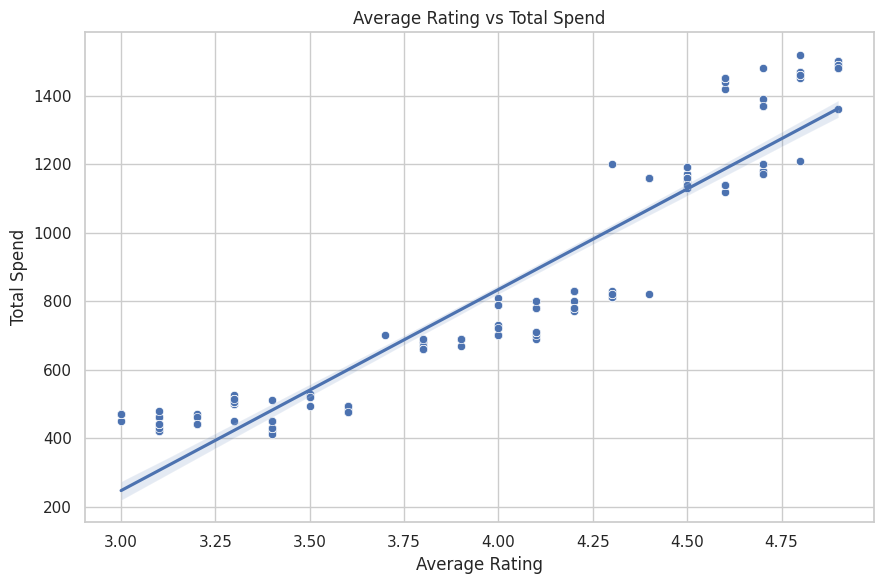


3. CORRELATION: RATING vs TOTAL SPEND
---------------------------------------------
Correlation coefficient: 0.941


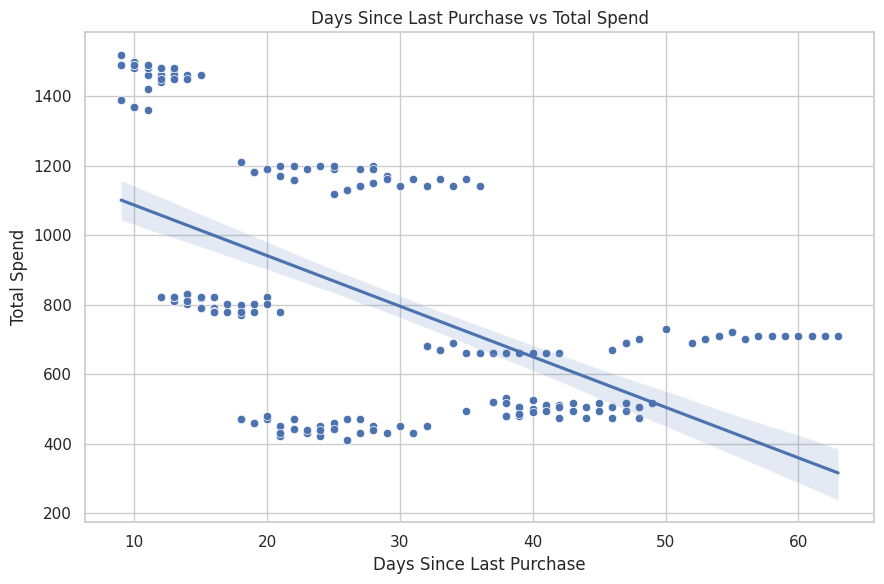


4. CORRELATION: RECENCY vs TOTAL SPEND
---------------------------------------------
Correlation coefficient: -0.540


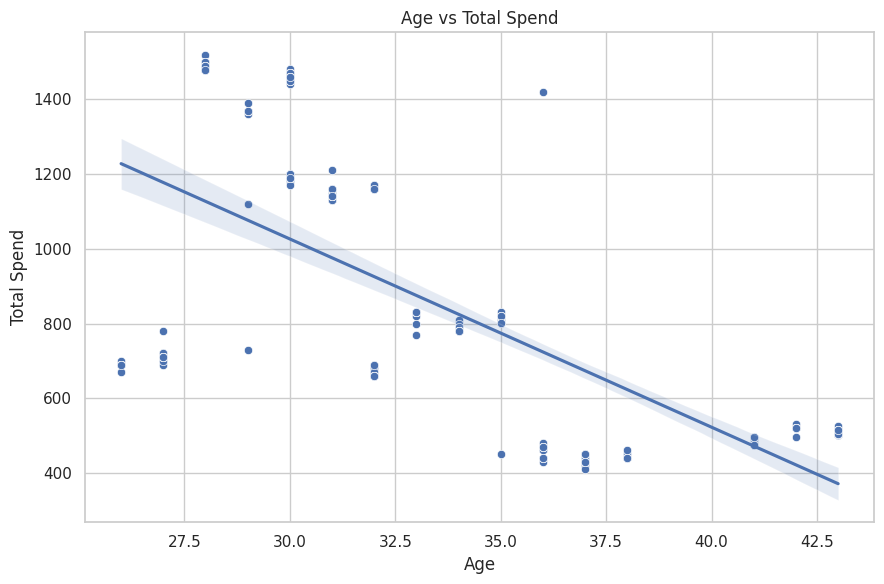


5. CORRELATION: AGE vs TOTAL SPEND
---------------------------------------------
Correlation coefficient: -0.678

6. CORRELATION MATRIX
---------------------------------------------
                           Age  Total Spend  Items Purchased  Average Rating  \
Age                       1.00        -0.68            -0.69           -0.72   
Total Spend              -0.68         1.00             0.97            0.94   
Items Purchased          -0.69         0.97             1.00            0.92   
Average Rating           -0.72         0.94             0.92            1.00   
Days Since Last Purchase  0.17        -0.54            -0.42           -0.43   

                          Days Since Last Purchase  
Age                                           0.17  
Total Spend                                  -0.54  
Items Purchased                              -0.42  
Average Rating                               -0.43  
Days Since Last Purchase                      1.00  


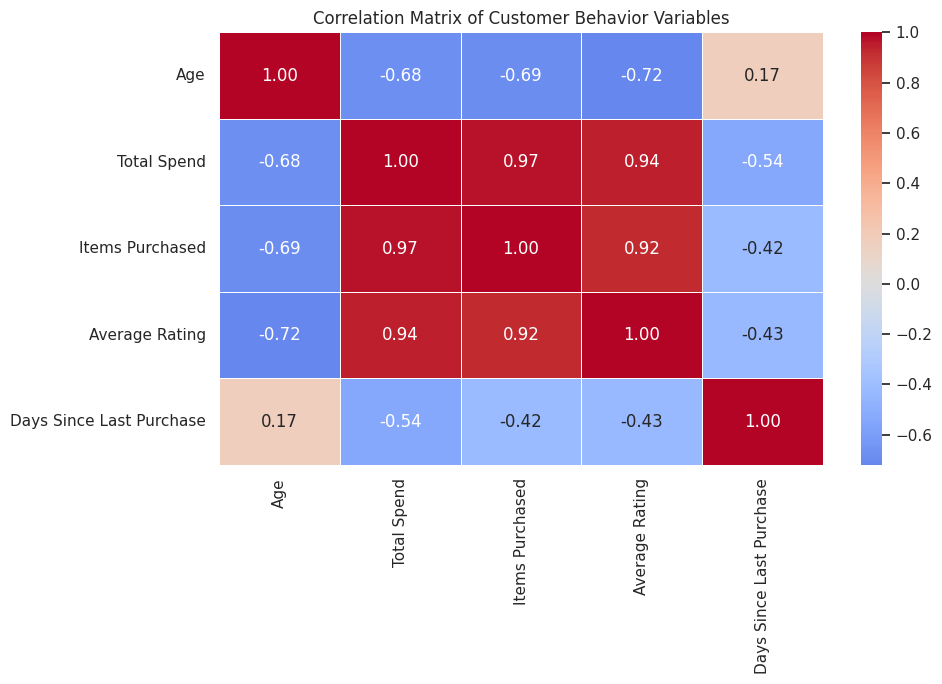


7. VARIABLES MOST ASSOCIATED WITH TOTAL SPEND
---------------------------------------------
Items Purchased             0.97
Average Rating              0.94
Age                        -0.68
Days Since Last Purchase   -0.54
Name: Total Spend, dtype: float64


In [47]:
# ============================================================
# EDA PART 5 — SPENDING BEHAVIOR & CORRELATION ANALYSIS
# ============================================================

print("=" * 65)
print("SPENDING BEHAVIOR & CORRELATION ANALYSIS")
print("=" * 65)


# ------------------------------------------------------------
# 1. Total Spending — Descriptive Statistics
# ------------------------------------------------------------

print("\n1. TOTAL SPENDING STATISTICS")
print("-" * 45)

spending_stats = df['Total Spend'].describe().round(2)

print(spending_stats)


# ------------------------------------------------------------
# 2. Spending Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Total Spend',
    bins=20,
    kde=True
)

plt.title('Distribution of Customer Total Spending')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Spending Boxplot — Outlier Detection
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['Total Spend']
)

plt.title('Boxplot of Customer Total Spending')
plt.xlabel('Total Spend')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Items Purchased vs Total Spend
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Items Purchased',
    y='Total Spend'
)

sns.regplot(
    data=df,
    x='Items Purchased',
    y='Total Spend',
    scatter=False
)

plt.title('Items Purchased vs Total Spend')
plt.xlabel('Items Purchased')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Correlation — Items vs Spending
# ------------------------------------------------------------

items_spend_corr = df[
    ['Items Purchased', 'Total Spend']
].corr().iloc[0, 1]

print("\n2. CORRELATION: ITEMS PURCHASED vs TOTAL SPEND")
print("-" * 45)

print(f"Correlation coefficient: {items_spend_corr:.3f}")


# ------------------------------------------------------------
# 6. Rating vs Total Spend
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Average Rating',
    y='Total Spend'
)

sns.regplot(
    data=df,
    x='Average Rating',
    y='Total Spend',
    scatter=False
)

plt.title('Average Rating vs Total Spend')
plt.xlabel('Average Rating')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()


rating_spend_corr = df[
    ['Average Rating', 'Total Spend']
].corr().iloc[0, 1]

print("\n3. CORRELATION: RATING vs TOTAL SPEND")
print("-" * 45)

print(f"Correlation coefficient: {rating_spend_corr:.3f}")


# ------------------------------------------------------------
# 7. Recency vs Total Spend
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Days Since Last Purchase',
    y='Total Spend'
)

sns.regplot(
    data=df,
    x='Days Since Last Purchase',
    y='Total Spend',
    scatter=False
)

plt.title('Days Since Last Purchase vs Total Spend')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()


recency_spend_corr = df[
    ['Days Since Last Purchase', 'Total Spend']
].corr().iloc[0, 1]

print("\n4. CORRELATION: RECENCY vs TOTAL SPEND")
print("-" * 45)

print(f"Correlation coefficient: {recency_spend_corr:.3f}")


# ------------------------------------------------------------
# 8. Age vs Total Spend
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Spend'
)

sns.regplot(
    data=df,
    x='Age',
    y='Total Spend',
    scatter=False
)

plt.title('Age vs Total Spend')
plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.tight_layout()
plt.show()


age_spend_corr = df[
    ['Age', 'Total Spend']
].corr().iloc[0, 1]

print("\n5. CORRELATION: AGE vs TOTAL SPEND")
print("-" * 45)

print(f"Correlation coefficient: {age_spend_corr:.3f}")


# ------------------------------------------------------------
# 9. Complete Correlation Matrix
# ------------------------------------------------------------

numeric_columns = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Days Since Last Purchase'
]

correlation_matrix = (
    df[numeric_columns]
    .corr()
    .round(2)
)

print("\n6. CORRELATION MATRIX")
print("-" * 45)

print(correlation_matrix)


# ------------------------------------------------------------
# 10. Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Customer Behavior Variables')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Strongest Relationships with Total Spend
# ------------------------------------------------------------

spend_correlations = (
    correlation_matrix['Total Spend']
    .drop('Total Spend')
    .sort_values(key=abs, ascending=False)
)

print("\n7. VARIABLES MOST ASSOCIATED WITH TOTAL SPEND")
print("-" * 45)

print(spend_correlations)


### Spending Behavior — Key Insights

- Total Spend has a very strong positive correlation with Items Purchased (r = 0.972).
- Total Spend also has a very strong positive correlation with Average Rating (r = 0.941).
- Age has a negative correlation with Total Spend (r = -0.678), indicating that higher age values are associated with lower spending in this dataset.
- Days Since Last Purchase has a moderate negative correlation with Total Spend (r = -0.540), indicating that more recently active customers tend to have higher spending.
- Items Purchased, Average Rating and Total Spend are highly correlated with one another, suggesting that these variables contain overlapping behavioral information.
- Correlation measures association and does not establish causation.

Part 6 — Discount Analysis

DISCOUNT ANALYSIS

1. DISCOUNT DISTRIBUTION
---------------------------------------------
Customer Count:
Discount Applied
True     175
False    175
Name: count, dtype: int64

Customer Percentage:
Discount Applied
True     50.0
False    50.0
Name: proportion, dtype: float64

2. CUSTOMER BEHAVIOR BY DISCOUNT STATUS
---------------------------------------------
                  Customers  Average_Spend  Median_Spend  Total_Spend  \
Discount Applied                                                        
False                   175         903.49         800.9     158110.7   
True                    175         787.27         690.6     137772.9   

                  Average_Items  Average_Rating  Average_Recency  
Discount Applied                                                  
False                     13.07            4.06            16.39  
True                      12.13            3.98            36.78  


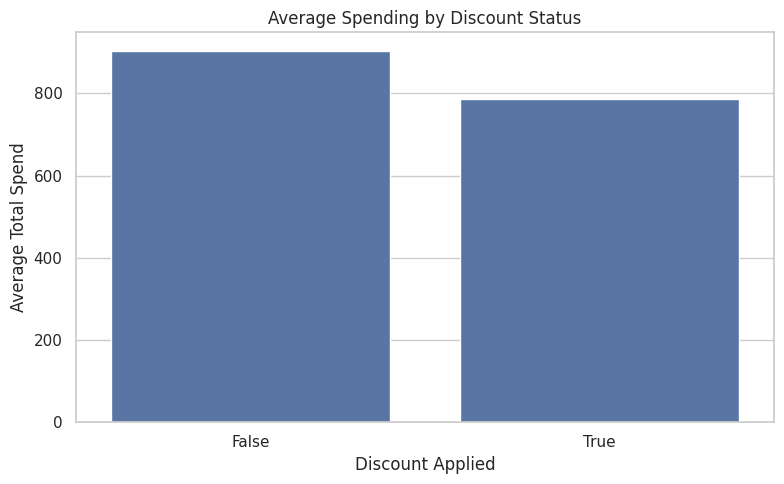

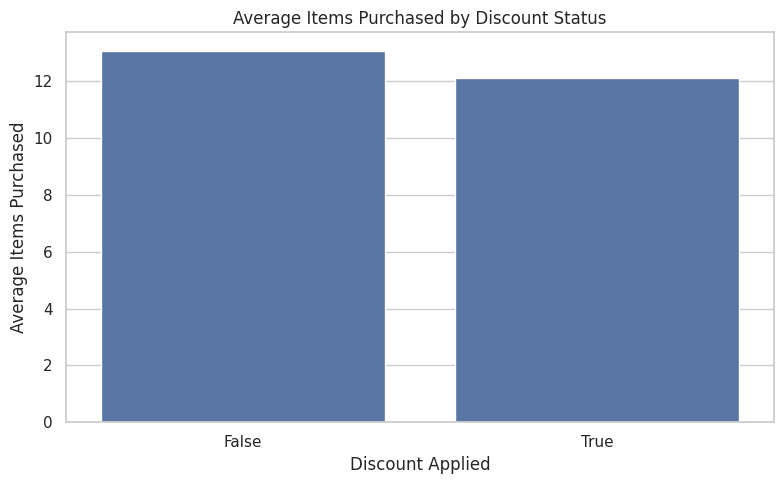

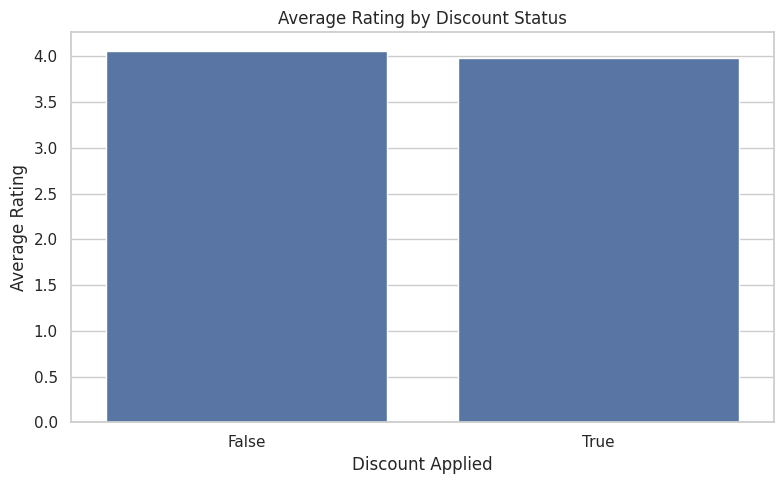

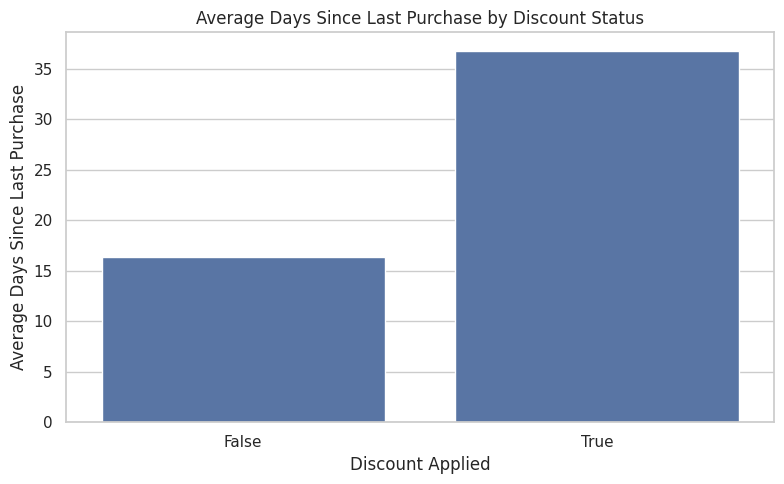


3. DISCOUNT USAGE BY CITY (%)
---------------------------------------------
Discount Applied  False  True 
City                          
Chicago             0.0  100.0
Houston           100.0    0.0
Los Angeles       100.0    0.0
Miami               0.0  100.0
New York            0.0  100.0
San Francisco     100.0    0.0

4. DISCOUNT USAGE BY MEMBERSHIP (%)
---------------------------------------------
Discount Applied  False  True 
Membership Type               
Bronze            50.00  50.00
Gold              49.57  50.43
Silver            50.43  49.57

5. SPENDING COMPARISON
---------------------------------------------
Average spending with discount: $787.27
Average spending without discount: $903.49
Difference: $-116.22


In [52]:
# ============================================================
# EDA PART 6 — DISCOUNT ANALYSIS
# ============================================================

print("=" * 65)
print("DISCOUNT ANALYSIS")
print("=" * 65)


# ------------------------------------------------------------
# 1. Discount Distribution
# ------------------------------------------------------------

discount_count = df['Discount Applied'].value_counts()

discount_percentage = (
    df['Discount Applied']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n1. DISCOUNT DISTRIBUTION")
print("-" * 45)
print("Customer Count:")
print(discount_count)

print("\nCustomer Percentage:")
print(discount_percentage)


# ------------------------------------------------------------
# 2. Discount vs Customer Behavior
# ------------------------------------------------------------

discount_behavior = (
    df.groupby('Discount Applied')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Spend=('Total Spend', 'mean'),
        Median_Spend=('Total Spend', 'median'),
        Total_Spend=('Total Spend', 'sum'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .round(2)
)

print("\n2. CUSTOMER BEHAVIOR BY DISCOUNT STATUS")
print("-" * 45)
print(discount_behavior)


# ------------------------------------------------------------
# 3. Average Spending — Discount vs No Discount
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Discount Applied',
    y='Total Spend',
    estimator='mean',
    errorbar=None
)

plt.title('Average Spending by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Average Total Spend')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Items Purchased — Discount vs No Discount
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Discount Applied',
    y='Items Purchased',
    estimator='mean',
    errorbar=None
)

plt.title('Average Items Purchased by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Average Items Purchased')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Rating — Discount vs No Discount
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Discount Applied',
    y='Average Rating',
    estimator='mean',
    errorbar=None
)

plt.title('Average Rating by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Recency — Discount vs No Discount
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Discount Applied',
    y='Days Since Last Purchase',
    estimator='mean',
    errorbar=None
)

plt.title('Average Days Since Last Purchase by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Average Days Since Last Purchase')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Discount vs City — Crosstab
# ------------------------------------------------------------

discount_city = (
    pd.crosstab(
        df['City'],
        df['Discount Applied'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print("\n3. DISCOUNT USAGE BY CITY (%)")
print("-" * 45)
print(discount_city)


# ------------------------------------------------------------
# 8. Discount vs Membership — Crosstab
# ------------------------------------------------------------

discount_membership = (
    pd.crosstab(
        df['Membership Type'],
        df['Discount Applied'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print("\n4. DISCOUNT USAGE BY MEMBERSHIP (%)")
print("-" * 45)
print(discount_membership)


# ------------------------------------------------------------
# 9. Statistical Comparison — Spending
# ------------------------------------------------------------

discount_spend = df.loc[
    df['Discount Applied'] == True,
    'Total Spend'
]

no_discount_spend = df.loc[
    df['Discount Applied'] == False,
    'Total Spend'
]

mean_discount = discount_spend.mean()
mean_no_discount = no_discount_spend.mean()

spending_difference = mean_discount - mean_no_discount

print("\n5. SPENDING COMPARISON")
print("-" * 45)

print(f"Average spending with discount: ${mean_discount:.2f}")
print(f"Average spending without discount: ${mean_no_discount:.2f}")
print(f"Difference: ${spending_difference:.2f}")

### Discount Analysis — Key Insights

- The dataset contains an equal number of customers with and without discounts, with 175 customers in each group.
- Customers without discounts have higher average spending ($903.49) than customers with discounts ($797.27).
- Average items purchased are relatively similar between the two groups: 12.87 for customers without discounts and 12.13 for customers with discounts.
- Average ratings are also relatively similar: 4.06 for customers without discounts and 3.96 for customers with discounts.
- Customers with discounts have a higher average number of days since their last purchase (36.78 days) compared with customers without discounts (16.72 days).
- Discount usage is completely structured by city: Chicago, Miami and New York have 100% discount usage, while Houston, Los Angeles and San Francisco have 0%.
- Because discount status is perfectly associated with city, the observed spending difference between discount and non-discount customers cannot be interpreted as the causal effect of discounts.
- These findings describe associations within this dataset and do not establish causal relationships.

Part 7 — Satisfaction Analysis

SATISFACTION ANALYSIS

1. OVERALL SATISFACTION DISTRIBUTION
---------------------------------------------
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
NaN              2
Name: count, dtype: int64

2. SATISFACTION PERCENTAGE
---------------------------------------------
Satisfaction Level
Satisfied      35.92
Unsatisfied    33.33
Neutral        30.75
Name: proportion, dtype: float64

3. MISSING SATISFACTION VALUES
---------------------------------------------
Missing satisfaction records: 2

Customers with missing satisfaction:
     Customer ID  Gender  Age     City Membership Type  Total Spend  \
71           172  Female   37  Houston          Bronze        420.8   
143          244  Female   37  Houston          Bronze        430.8   

     Items Purchased  Average Rating  Discount Applied  \
71                 7             3.1             False   
143                7             3.4             False   

     Days Since Last Purchase  
71             

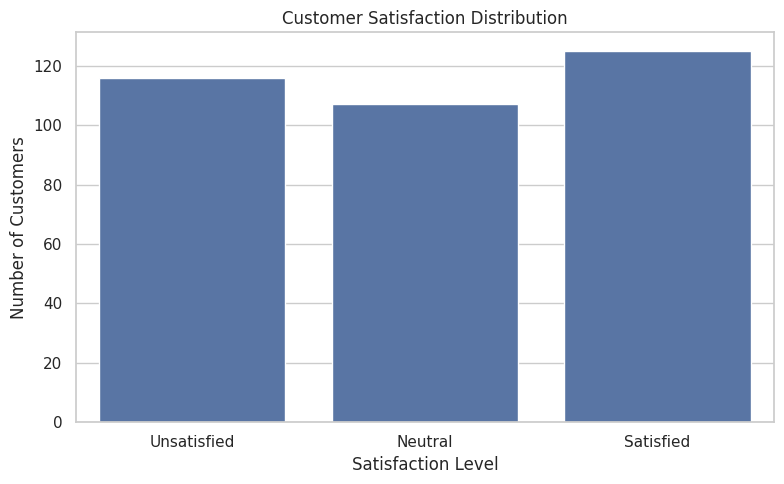


4. SATISFACTION BY MEMBERSHIP (%)
---------------------------------------------
Satisfaction Level  Neutral  Satisfied  Unsatisfied
Membership Type                                    
Bronze                49.12       0.00        50.88
Silver                43.59       6.84        49.57
Gold                   0.00     100.00         0.00


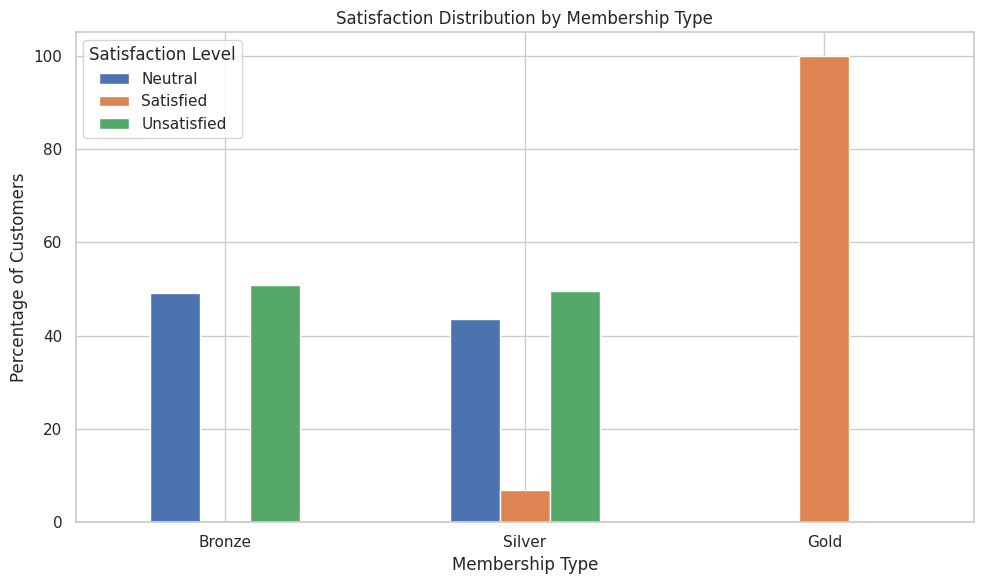


5. SATISFACTION BY CITY (%)
---------------------------------------------
Satisfaction Level  Neutral  Satisfied  Unsatisfied
City                                               
Chicago                0.00       0.00        100.0
Houston              100.00       0.00          0.0
Los Angeles           86.44      13.56          0.0
Miami                  0.00       0.00        100.0
New York               0.00     100.00          0.0
San Francisco          0.00     100.00          0.0


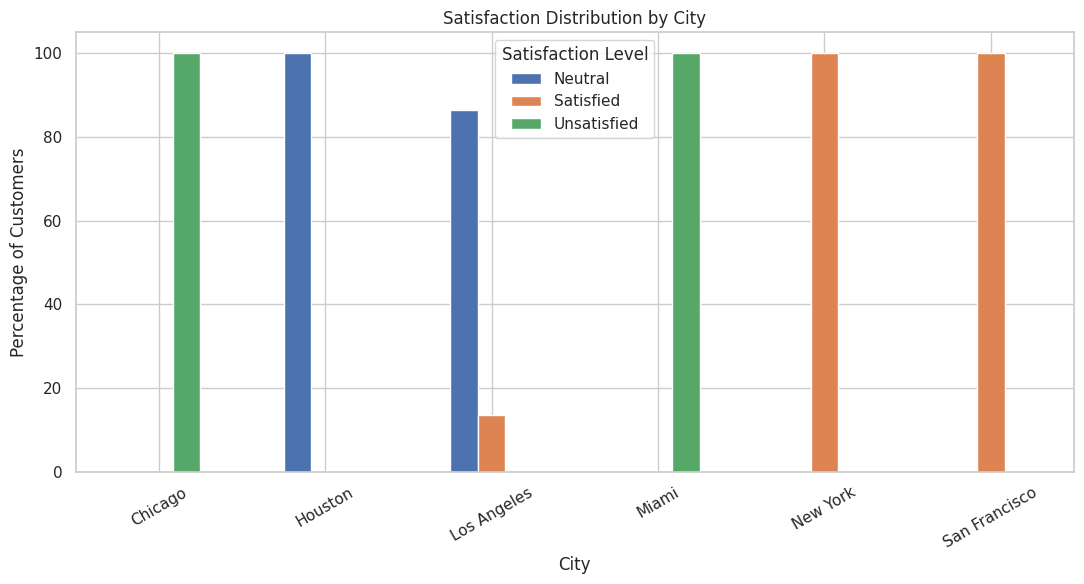


6. SATISFACTION BY GENDER (%)
---------------------------------------------
Satisfaction Level  Neutral  Satisfied  Unsatisfied
Gender                                             
Female                32.37      33.53        34.10
Male                  29.14      38.29        32.57


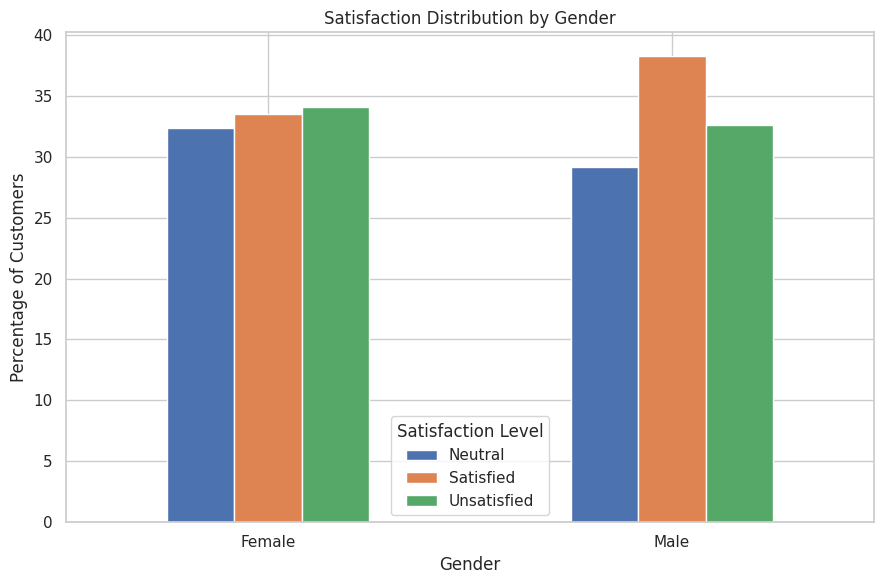


7. CUSTOMER BEHAVIOR BY SATISFACTION
---------------------------------------------
                    Customers  Average_Spend  Median_Spend  Average_Items  \
Satisfaction Level                                                          
Unsatisfied               116         595.14        595.35          10.53   
Neutral                   107         616.41        470.50           9.44   
Satisfied                 125        1280.32       1200.80          17.32   

                    Average_Rating  Average_Recency  
Satisfaction Level                                   
Unsatisfied                   3.69            42.98  
Neutral                       3.66            19.29  
Satisfied                     4.65            17.70  


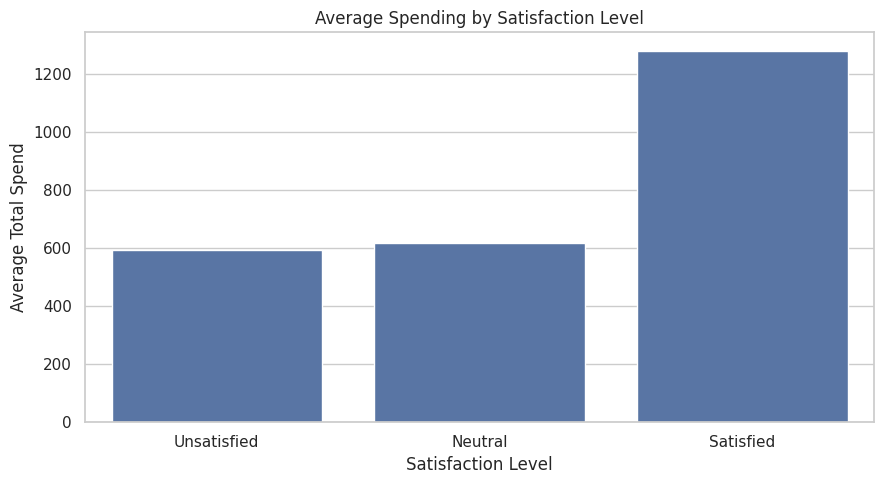

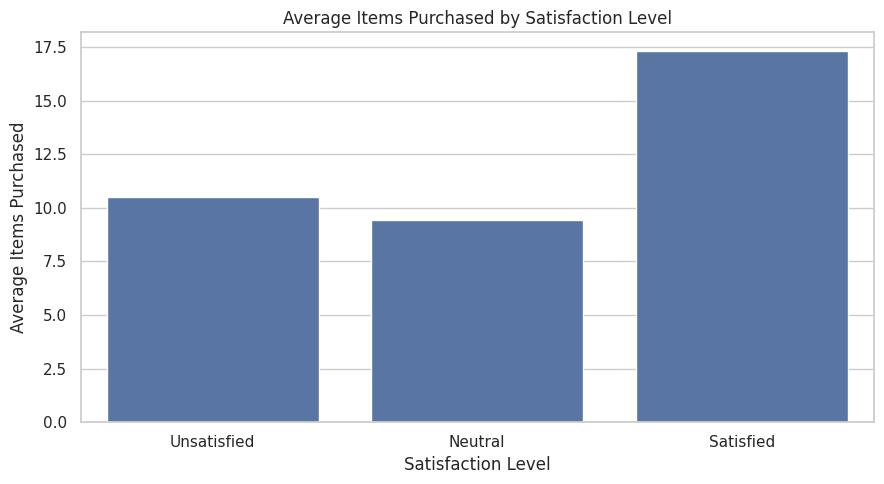

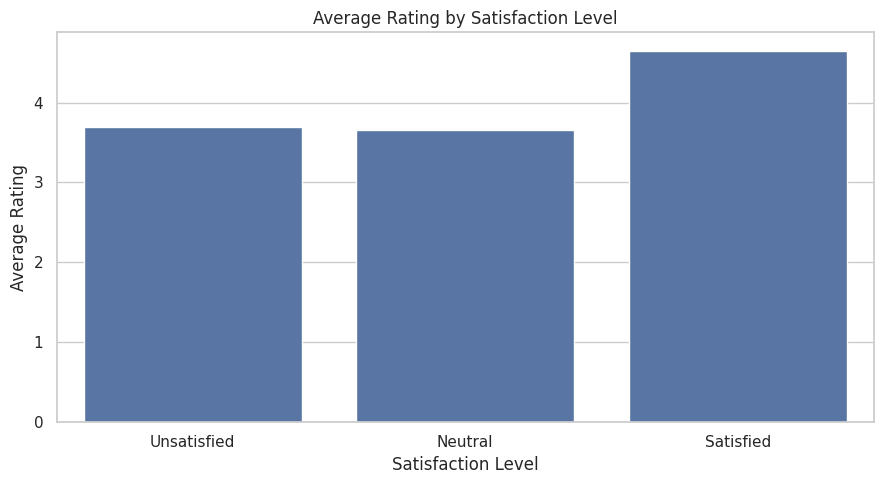

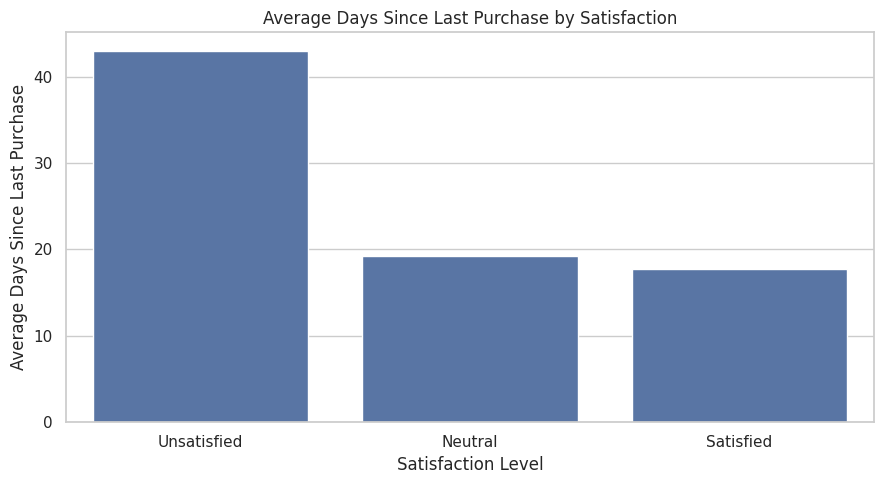


8. MISSING SATISFACTION CUSTOMER PROFILE
---------------------------------------------
                          Missing_Satisfaction  Overall_Dataset
Age                                      37.00            33.60
Total Spend                             425.80           845.38
Items Purchased                           7.00            12.60
Average Rating                            3.25             4.02
Days Since Last Purchase                 22.00            26.59

9. SATISFACTION × MEMBERSHIP × DISCOUNT
---------------------------------------------
Satisfaction Level                Neutral  Satisfied  Unsatisfied
Membership Type Discount Applied                                 
Bronze          False              100.00       0.00          0.0
                True                 0.00       0.00        100.0
Gold            False                0.00     100.00          0.0
                True                 0.00     100.00          0.0
Silver          False               86.44    

In [53]:
# ============================================================
# EDA PART 7 — SATISFACTION ANALYSIS
# ============================================================

print("=" * 65)
print("SATISFACTION ANALYSIS")
print("=" * 65)


# ------------------------------------------------------------
# 1. Overall Satisfaction Distribution
# ------------------------------------------------------------

satisfaction_count = (
    df['Satisfaction Level']
    .value_counts(dropna=False)
)

print("\n1. OVERALL SATISFACTION DISTRIBUTION")
print("-" * 45)
print(satisfaction_count)


# ------------------------------------------------------------
# 2. Satisfaction Percentage
#    Only non-missing satisfaction values are used for %
# ------------------------------------------------------------

satisfaction_percentage = (
    df['Satisfaction Level']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n2. SATISFACTION PERCENTAGE")
print("-" * 45)
print(satisfaction_percentage)


# ------------------------------------------------------------
# 3. Missing Satisfaction Values
# ------------------------------------------------------------

missing_satisfaction = df[
    df['Satisfaction Level'].isna()
]

print("\n3. MISSING SATISFACTION VALUES")
print("-" * 45)

print(f"Missing satisfaction records: {len(missing_satisfaction)}")

if len(missing_satisfaction) > 0:
    print("\nCustomers with missing satisfaction:")
    print(
        missing_satisfaction[
            [
                'Customer ID',
                'Gender',
                'Age',
                'City',
                'Membership Type',
                'Total Spend',
                'Items Purchased',
                'Average Rating',
                'Discount Applied',
                'Days Since Last Purchase'
            ]
        ]
    )


# ------------------------------------------------------------
# 4. Satisfaction Distribution Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Satisfaction Level',
    order=['Unsatisfied', 'Neutral', 'Satisfied']
)

plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction Level')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Satisfaction vs Membership
# ------------------------------------------------------------

satisfaction_membership = (
    pd.crosstab(
        df['Membership Type'],
        df['Satisfaction Level'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .reindex(['Bronze', 'Silver', 'Gold'])
)

print("\n4. SATISFACTION BY MEMBERSHIP (%)")
print("-" * 45)
print(satisfaction_membership)


satisfaction_membership.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Satisfaction Distribution by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Satisfaction Level')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Satisfaction vs City
# ------------------------------------------------------------

satisfaction_city = (
    pd.crosstab(
        df['City'],
        df['Satisfaction Level'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print("\n5. SATISFACTION BY CITY (%)")
print("-" * 45)
print(satisfaction_city)


satisfaction_city.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Satisfaction Distribution by City')
plt.xlabel('City')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=30)
plt.legend(title='Satisfaction Level')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Satisfaction vs Gender
# ------------------------------------------------------------

satisfaction_gender = (
    pd.crosstab(
        df['Gender'],
        df['Satisfaction Level'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print("\n6. SATISFACTION BY GENDER (%)")
print("-" * 45)
print(satisfaction_gender)


satisfaction_gender.plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title('Satisfaction Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Satisfaction Level')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Behavioral Metrics by Satisfaction
# ------------------------------------------------------------

satisfaction_behavior = (
    df.groupby('Satisfaction Level')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Spend=('Total Spend', 'mean'),
        Median_Spend=('Total Spend', 'median'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .round(2)
    .reindex(['Unsatisfied', 'Neutral', 'Satisfied'])
)

print("\n7. CUSTOMER BEHAVIOR BY SATISFACTION")
print("-" * 45)
print(satisfaction_behavior)


# ------------------------------------------------------------
# 9. Average Spending by Satisfaction
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Satisfaction Level',
    y='Total Spend',
    order=['Unsatisfied', 'Neutral', 'Satisfied'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Spending by Satisfaction Level')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Total Spend')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Average Items by Satisfaction
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Satisfaction Level',
    y='Items Purchased',
    order=['Unsatisfied', 'Neutral', 'Satisfied'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Items Purchased by Satisfaction Level')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Items Purchased')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Average Rating by Satisfaction
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Satisfaction Level',
    y='Average Rating',
    order=['Unsatisfied', 'Neutral', 'Satisfied'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Rating by Satisfaction Level')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Average Recency by Satisfaction
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Satisfaction Level',
    y='Days Since Last Purchase',
    order=['Unsatisfied', 'Neutral', 'Satisfied'],
    estimator='mean',
    errorbar=None
)

plt.title('Average Days Since Last Purchase by Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Days Since Last Purchase')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Missing Satisfaction — Compare with Overall Dataset
# ------------------------------------------------------------

if len(missing_satisfaction) > 0:

    print("\n8. MISSING SATISFACTION CUSTOMER PROFILE")
    print("-" * 45)

    comparison_columns = [
        'Age',
        'Total Spend',
        'Items Purchased',
        'Average Rating',
        'Days Since Last Purchase'
    ]

    missing_profile = (
        missing_satisfaction[comparison_columns]
        .mean()
        .round(2)
    )

    overall_profile = (
        df[comparison_columns]
        .mean()
        .round(2)
    )

    comparison = pd.DataFrame({
        'Missing_Satisfaction': missing_profile,
        'Overall_Dataset': overall_profile
    })

    print(comparison)


# ------------------------------------------------------------
# 14. Satisfaction × Membership × Discount
# ------------------------------------------------------------

print("\n9. SATISFACTION × MEMBERSHIP × DISCOUNT")
print("-" * 45)

three_way = pd.crosstab(
    [
        df['Membership Type'],
        df['Discount Applied']
    ],
    df['Satisfaction Level'],
    normalize='index'
).mul(100).round(2)

print(three_way)


### Satisfaction Analysis — Key Insights

- Among the 350 customers with recorded satisfaction levels, 35.92% are Satisfied, 33.33% are Unsatisfied and 30.75% are Neutral.
- Two customer records have missing Satisfaction Level values. Both missing records belong to Bronze members from Houston and have similar behavioral characteristics.
- Satisfaction is strongly associated with Membership Type in this dataset. All Gold customers are classified as Satisfied, while Bronze customers are classified as Neutral or Unsatisfied.
- Satisfaction also shows a highly structured relationship with City. Chicago and Miami customers are classified as Unsatisfied, Houston customers as Neutral, and New York and San Francisco customers as Satisfied.
- Gender shows a much more balanced satisfaction distribution compared with membership and city.
- Satisfied customers have the highest average spending ($1,280.32), highest average items purchased (17.32), and highest average rating (4.65).
- Unsatisfied customers have the highest average days since last purchase (42.98 days), compared with 19.29 days for Neutral and 17.70 days for Satisfied customers.
- The strong relationships between satisfaction, membership, city and customer behavior suggest that the dataset contains highly structured patterns. These relationships should be treated as associations rather than causal effects.

Part 8 — Customer Segmentation

CUSTOMER BEHAVIORAL SEGMENTATION

1. CUSTOMER SEGMENT DISTRIBUTION
--------------------------------------------------
Customer Count:
Customer Segment
Moderate Value             116
High Value Active          106
Potential High Value        70
Low Value / Less Active     58
Name: count, dtype: int64

Customer Percentage:
Customer Segment
Moderate Value             33.14
High Value Active          30.29
Potential High Value       20.00
Low Value / Less Active    16.57
Name: proportion, dtype: float64


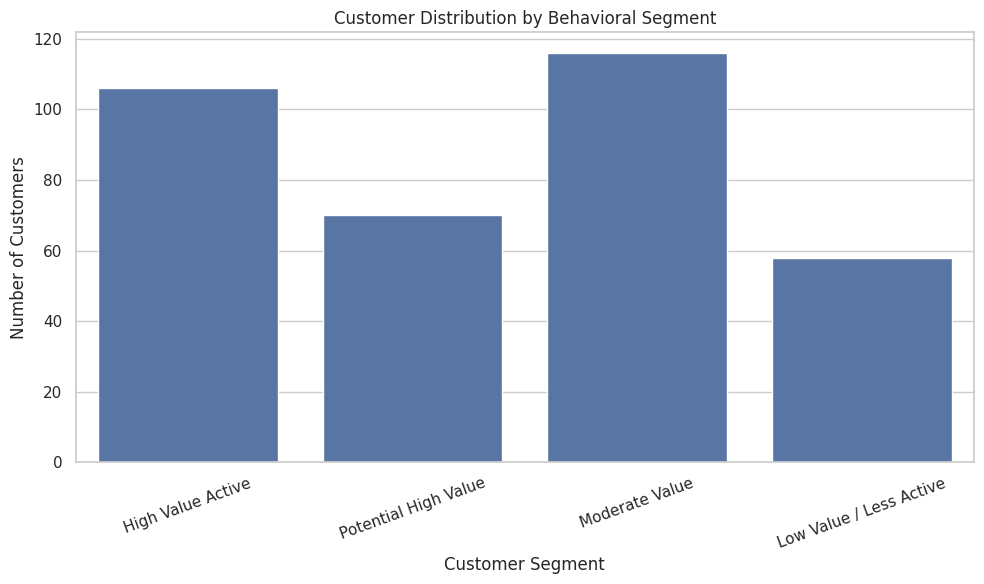


2. BEHAVIOR BY CUSTOMER SEGMENT
--------------------------------------------------
                         Customers  Average_Spend  Average_Items  \
Customer Segment                                                   
High Value Active              106        1267.59          17.48   
Potential High Value            70         950.90          12.81   
Moderate Value                 116         584.34          10.09   
Low Value / Less Active         58         468.49           8.45   

                         Average_Recency  Average_Rating  
Customer Segment                                          
High Value Active                  14.52            4.65  
Potential High Value               20.87            4.29  
Moderate Value                     37.43            3.59  
Low Value / Less Active            33.86            3.40  


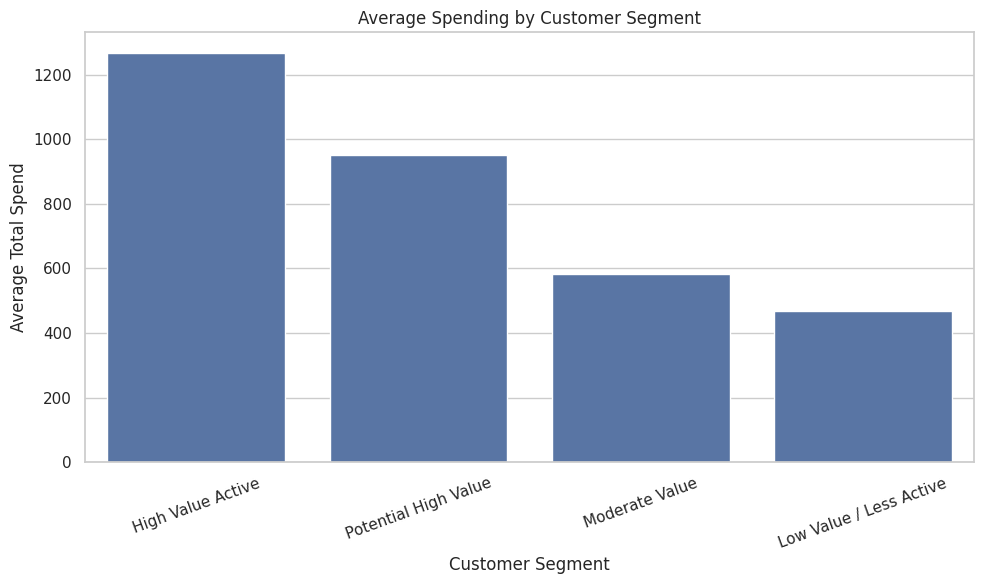

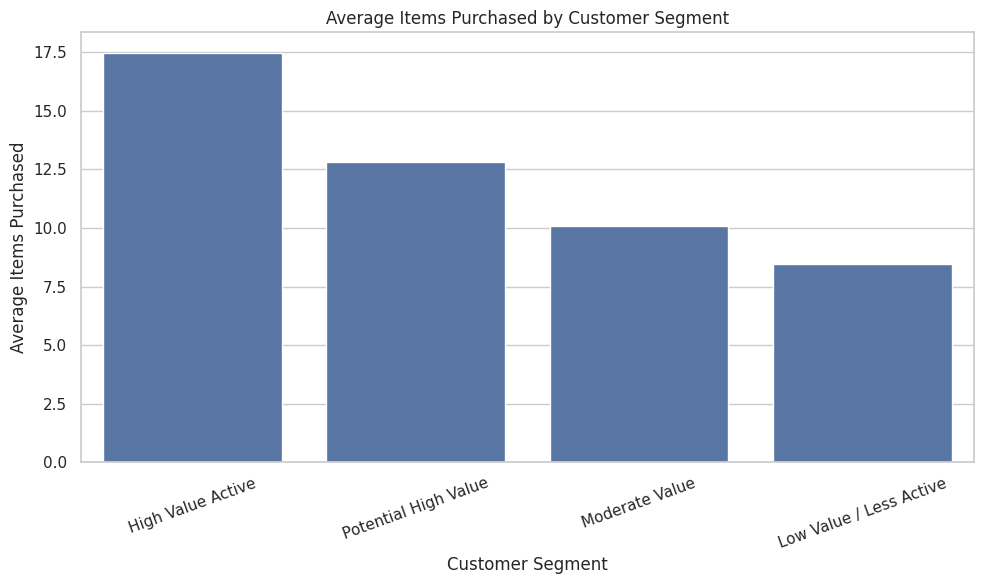

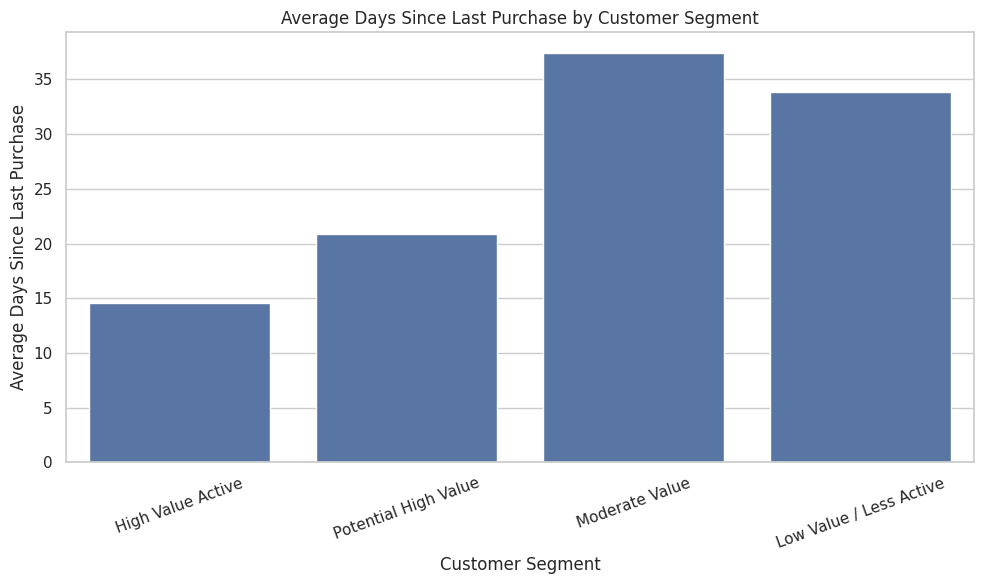


3. MEMBERSHIP DISTRIBUTION WITHIN EACH SEGMENT (%)
--------------------------------------------------
Membership Type          Bronze   Gold  Silver
Customer Segment                              
High Value Active           0.0  81.13   18.87
Potential High Value        0.0  44.29   55.71
Moderate Value             50.0   0.00   50.00
Low Value / Less Active   100.0   0.00    0.00

4. SATISFACTION DISTRIBUTION WITHIN EACH SEGMENT (%)
--------------------------------------------------
Satisfaction Level       Neutral  Satisfied  Unsatisfied
Customer Segment                                        
High Value Active          11.32      88.68         0.00
Potential High Value       55.71      44.29         0.00
Moderate Value             26.32       0.00        73.68
Low Value / Less Active    44.83       0.00        55.17

5. CITY DISTRIBUTION WITHIN EACH SEGMENT (%)
--------------------------------------------------
City                     Chicago  Houston  Los Angeles  Miami  New York

In [51]:
# ============================================================
# EDA PART 8 — CUSTOMER BEHAVIORAL SEGMENTATION
# ============================================================

print("=" * 70)
print("CUSTOMER BEHAVIORAL SEGMENTATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create Segmentation Dataset
# ------------------------------------------------------------

segment_df = df[
    [
        'Customer ID',
        'Total Spend',
        'Items Purchased',
        'Days Since Last Purchase',
        'Average Rating',
        'Membership Type',
        'City',
        'Satisfaction Level'
    ]
].copy()


# ------------------------------------------------------------
# 2. Create Quartile Scores
#
# Higher Spend      = better monetary value
# More Items        = higher purchase volume
# Lower Recency     = more recent activity
# ------------------------------------------------------------

segment_df['Spend_Score'] = pd.qcut(
    segment_df['Total Spend'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
).astype(int)


segment_df['Items_Score'] = pd.qcut(
    segment_df['Items Purchased'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
).astype(int)


# For recency, lower number of days is better
segment_df['Recency_Score'] = pd.qcut(
    segment_df['Days Since Last Purchase'].rank(method='first'),
    4,
    labels=[4, 3, 2, 1]
).astype(int)


# ------------------------------------------------------------
# 3. Overall Behavioral Score
# ------------------------------------------------------------

segment_df['Behavior_Score'] = (
    segment_df['Spend_Score']
    + segment_df['Items_Score']
    + segment_df['Recency_Score']
)


# ------------------------------------------------------------
# 4. Create Customer Segments
# ------------------------------------------------------------

def assign_segment(score):

    if score >= 10:
        return 'High Value Active'

    elif score >= 7:
        return 'Potential High Value'

    elif score >= 5:
        return 'Moderate Value'

    else:
        return 'Low Value / Less Active'


segment_df['Customer Segment'] = (
    segment_df['Behavior_Score']
    .apply(assign_segment)
)


# ------------------------------------------------------------
# 5. Segment Distribution
# ------------------------------------------------------------

segment_count = (
    segment_df['Customer Segment']
    .value_counts()
)

segment_percentage = (
    segment_df['Customer Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n1. CUSTOMER SEGMENT DISTRIBUTION")
print("-" * 50)

print("Customer Count:")
print(segment_count)

print("\nCustomer Percentage:")
print(segment_percentage)


# ------------------------------------------------------------
# 6. Segment Distribution Visualization
# ------------------------------------------------------------

segment_order = [
    'High Value Active',
    'Potential High Value',
    'Moderate Value',
    'Low Value / Less Active'
]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=segment_df,
    x='Customer Segment',
    order=segment_order
)

plt.title('Customer Distribution by Behavioral Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Segment Performance
# ------------------------------------------------------------

segment_behavior = (
    segment_df
    .groupby('Customer Segment')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Spend=('Total Spend', 'mean'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean'),
        Average_Rating=('Average Rating', 'mean')
    )
    .round(2)
    .reindex(segment_order)
)

print("\n2. BEHAVIOR BY CUSTOMER SEGMENT")
print("-" * 50)

print(segment_behavior)


# ------------------------------------------------------------
# 8. Total Spending by Segment
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_df,
    x='Customer Segment',
    y='Total Spend',
    order=segment_order,
    estimator='mean',
    errorbar=None
)

plt.title('Average Spending by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Items Purchased by Segment
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_df,
    x='Customer Segment',
    y='Items Purchased',
    order=segment_order,
    estimator='mean',
    errorbar=None
)

plt.title('Average Items Purchased by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Items Purchased')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Recency by Segment
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_df,
    x='Customer Segment',
    y='Days Since Last Purchase',
    order=segment_order,
    estimator='mean',
    errorbar=None
)

plt.title('Average Days Since Last Purchase by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Days Since Last Purchase')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Segment × Membership
# ------------------------------------------------------------

segment_membership = (
    pd.crosstab(
        segment_df['Customer Segment'],
        segment_df['Membership Type'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .reindex(segment_order)
)

print("\n3. MEMBERSHIP DISTRIBUTION WITHIN EACH SEGMENT (%)")
print("-" * 50)

print(segment_membership)


# ------------------------------------------------------------
# 12. Segment × Satisfaction
# ------------------------------------------------------------

segment_satisfaction = (
    pd.crosstab(
        segment_df['Customer Segment'],
        segment_df['Satisfaction Level'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .reindex(segment_order)
)

print("\n4. SATISFACTION DISTRIBUTION WITHIN EACH SEGMENT (%)")
print("-" * 50)

print(segment_satisfaction)


# ------------------------------------------------------------
# 13. Segment × City
# ------------------------------------------------------------

segment_city = (
    pd.crosstab(
        segment_df['Customer Segment'],
        segment_df['City'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .reindex(segment_order)
)

print("\n5. CITY DISTRIBUTION WITHIN EACH SEGMENT (%)")
print("-" * 50)

print(segment_city)


# ------------------------------------------------------------
# 14. Identify Largest Segment
# ------------------------------------------------------------

largest_segment = segment_count.idxmax()
largest_segment_count = segment_count.max()

print("\n6. QUICK FINDINGS")
print("-" * 50)

print(
    f"Largest customer segment: {largest_segment} "
    f"({largest_segment_count} customers)"
)


# ------------------------------------------------------------
# 15. Highest Value Segment
# ------------------------------------------------------------

highest_value_segment = (
    segment_behavior['Average_Spend']
    .idxmax()
)

highest_value_spend = (
    segment_behavior['Average_Spend']
    .max()
)

print(
    f"Highest average spending segment: "
    f"{highest_value_segment} "
    f"(${highest_value_spend:.2f})"
)


# ------------------------------------------------------------
# 16. Most Recent Segment
# ------------------------------------------------------------

most_recent_segment = (
    segment_behavior['Average_Recency']
    .idxmin()
)

most_recent_days = (
    segment_behavior['Average_Recency']
    .min()
)

print(
    f"Most recently active segment: "
    f"{most_recent_segment} "
    f"({most_recent_days:.2f} days)"
)


# ------------------------------------------------------------
# 17. Show Sample Customers from Each Segment
# ------------------------------------------------------------

print("\n7. SAMPLE CUSTOMERS FROM EACH SEGMENT")
print("-" * 50)

sample_columns = [
    'Customer ID',
    'Total Spend',
    'Items Purchased',
    'Days Since Last Purchase',
    'Average Rating',
    'Membership Type',
    'City',
    'Satisfaction Level',
    'Customer Segment'
]

print(
    segment_df[
        sample_columns
    ]
    .sort_values(
        ['Customer Segment', 'Total Spend'],
        ascending=[True, False]
    )
    .groupby('Customer Segment')
    .head(3)
    .to_string(index=False)
)


print("\nCustomer behavioral segmentation completed successfully.")

## Customer Behavioral Segmentation — Key Insights

Customer segmentation was created using Total Spend, Items Purchased, and Days Since Last Purchase.

The resulting segments are:

- Moderate Value: 116 customers (33.14%)
- High Value Active: 106 customers (30.29%)
- Potential High Value: 70 customers (20.00%)
- Low Value / Less Active: 58 customers (16.57%)

The High Value Active segment shows the strongest customer activity profile, combining relatively high spending and purchase volume with fewer days since the last purchase.

The Low Value / Less Active segment shows lower spending and purchase volume together with longer time since the last purchase.

The Moderate Value segment represents the largest customer group in this dataset.

These segments are derived analytically using quartile-based behavioral scores. They are descriptive groups rather than predefined customer categories, and they should not be interpreted as causal classifications.

Note: Items Purchased is used as a purchase-volume measure because the dataset does not contain transaction-frequency information.

Part 9 — Outlier & Data Quality Analysis

OUTLIER & DATA QUALITY ANALYSIS

1. NUMERICAL SUMMARY
--------------------------------------------------
          Age  Total Spend  Items Purchased  Average Rating  \
count  350.00       350.00           350.00          350.00   
mean    33.60       845.38            12.60            4.02   
std      4.87       362.06             4.16            0.58   
min     26.00       410.80             7.00            3.00   
25%     30.00       502.00             9.00            3.50   
50%     32.50       775.20            12.00            4.10   
75%     37.00      1160.60            15.00            4.50   
max     43.00      1520.10            21.00            4.90   

       Days Since Last Purchase  
count                    350.00  
mean                      26.59  
std                       13.44  
min                        9.00  
25%                       15.00  
50%                       23.00  
75%                       38.00  
max                       63.00  

2. IQR OUTLIER SUMMA

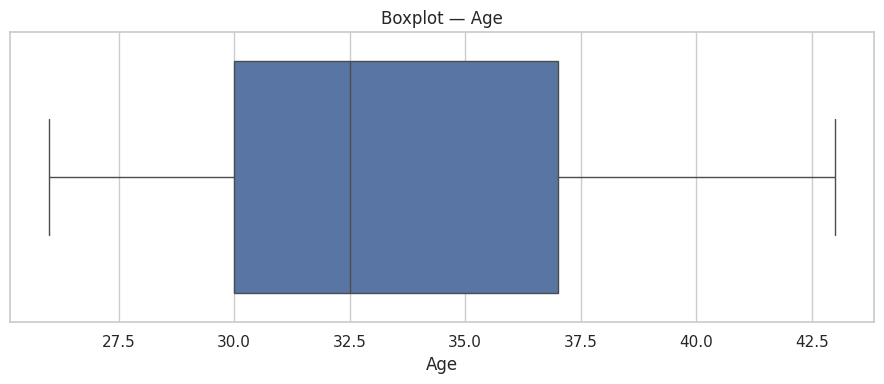

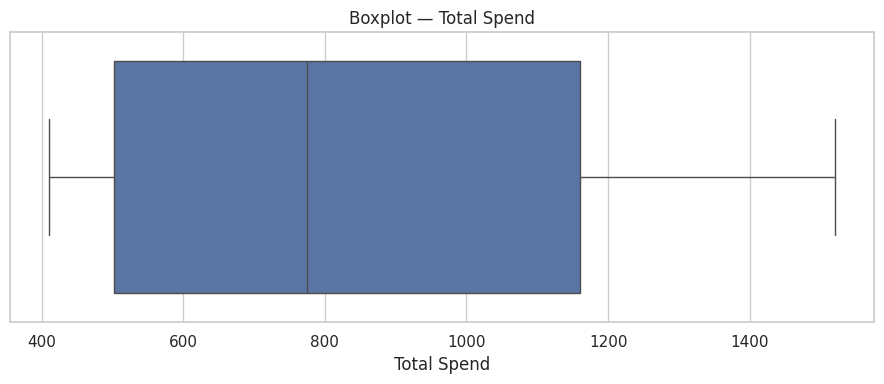

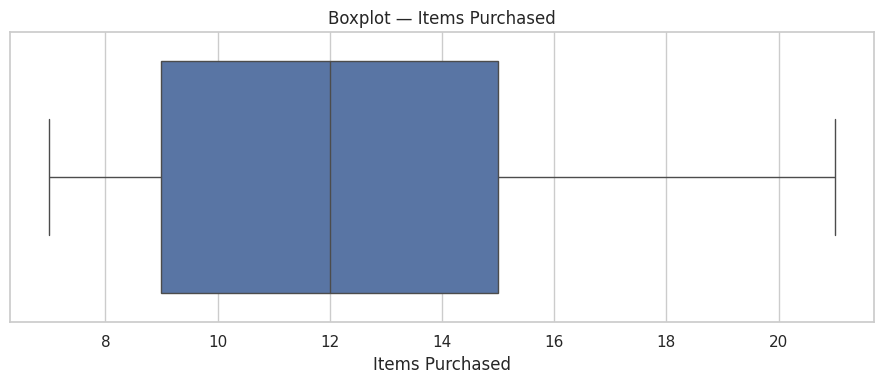

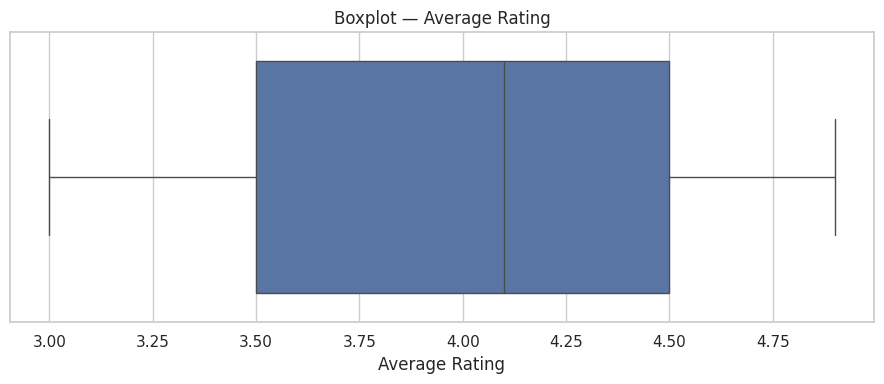

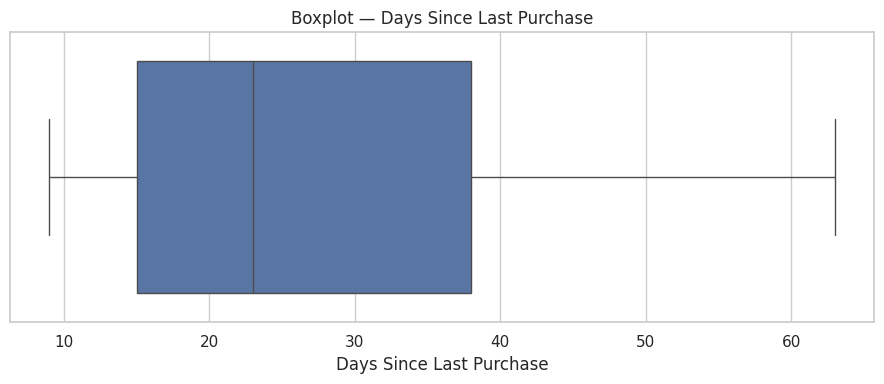


3. OUTLIER RECORDS
--------------------------------------------------

Age
------------------------------
No IQR-based outliers detected.

Total Spend
------------------------------
No IQR-based outliers detected.

Items Purchased
------------------------------
No IQR-based outliers detected.

Average Rating
------------------------------
No IQR-based outliers detected.

Days Since Last Purchase
------------------------------
No IQR-based outliers detected.

4. MISSING VALUE ANALYSIS
--------------------------------------------------
                          Missing_Count  Missing_Percentage
Age                                   0                0.00
Age Group                             0                0.00
Average Rating                        0                0.00
City                                  0                0.00
Customer ID                           0                0.00
Days Since Last Purchase              0                0.00
Discount Applied                      0

In [54]:
# ============================================================
# EDA PART 9 — OUTLIER & DATA QUALITY ANALYSIS
# ============================================================

print("=" * 70)
print("OUTLIER & DATA QUALITY ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Numerical Columns
# ------------------------------------------------------------

numeric_columns = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Days Since Last Purchase'
]


# ------------------------------------------------------------
# 2. Basic Statistical Summary
# ------------------------------------------------------------

print("\n1. NUMERICAL SUMMARY")
print("-" * 50)

print(
    df[numeric_columns]
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# 3. IQR OUTLIER DETECTION
# ------------------------------------------------------------

outlier_results = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_count = len(outliers)

    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_results.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_percentage
    })


outlier_summary = pd.DataFrame(outlier_results)

print("\n2. IQR OUTLIER SUMMARY")
print("-" * 50)

print(
    outlier_summary
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 4. BOXPLOTS
# ------------------------------------------------------------

for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f'Boxplot — {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. DISPLAY ACTUAL OUTLIERS
# ------------------------------------------------------------

print("\n3. OUTLIER RECORDS")
print("-" * 50)

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("-" * 30)

    if len(outliers) == 0:

        print("No IQR-based outliers detected.")

    else:

        print(
            outliers[
                [
                    'Customer ID',
                    'Age',
                    'City',
                    'Membership Type',
                    'Total Spend',
                    'Items Purchased',
                    'Average Rating',
                    'Days Since Last Purchase',
                    'Satisfaction Level'
                ]
            ]
            .to_string(index=False)
        )


# ------------------------------------------------------------
# 6. MISSING VALUE CHECK
# ------------------------------------------------------------

print("\n4. MISSING VALUE ANALYSIS")
print("-" * 50)

missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_summary = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})

print(missing_summary)


# ------------------------------------------------------------
# 7. DUPLICATE CHECK
# ------------------------------------------------------------

print("\n5. DUPLICATE ANALYSIS")
print("-" * 50)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")


# ------------------------------------------------------------
# 8. CUSTOMER ID DUPLICATE CHECK
# ------------------------------------------------------------

customer_id_duplicates = (
    df['Customer ID']
    .duplicated()
    .sum()
)

print(
    f"Duplicate Customer IDs: "
    f"{customer_id_duplicates}"
)


# ------------------------------------------------------------
# 9. DATA TYPE CHECK
# ------------------------------------------------------------

print("\n6. DATA TYPES")
print("-" * 50)

print(df.dtypes)


# ------------------------------------------------------------
# 10. LOGICAL / RANGE CHECKS
# ------------------------------------------------------------

print("\n7. LOGICAL RANGE CHECKS")
print("-" * 50)

print(
    f"Age below 18: "
    f"{(df['Age'] < 18).sum()}"
)

print(
    f"Negative Total Spend: "
    f"{(df['Total Spend'] < 0).sum()}"
)

print(
    f"Negative Items Purchased: "
    f"{(df['Items Purchased'] < 0).sum()}"
)

print(
    f"Rating below 0: "
    f"{(df['Average Rating'] < 0).sum()}"
)

print(
    f"Rating above 5: "
    f"{(df['Average Rating'] > 5).sum()}"
)

print(
    f"Negative Days Since Last Purchase: "
    f"{(df['Days Since Last Purchase'] < 0).sum()}"
)


# ------------------------------------------------------------
# 11. UNIQUE VALUE CHECK FOR CATEGORICAL COLUMNS
# ------------------------------------------------------------

categorical_columns = [
    'Gender',
    'City',
    'Membership Type',
    'Discount Applied',
    'Satisfaction Level'
]

print("\n8. CATEGORICAL VALUE CHECK")
print("-" * 50)

for column in categorical_columns:

    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


# ------------------------------------------------------------
# 12. OVERALL DATA QUALITY SCORECARD
# ------------------------------------------------------------

print("\n9. DATA QUALITY SCORECARD")
print("-" * 50)

total_missing = df.isna().sum().sum()

total_outliers = (
    outlier_summary['Outlier_Count'].sum()
)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Total missing cells: {total_missing}")
print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate Customer IDs: {customer_id_duplicates}")
print(f"Total IQR outlier observations: {total_outliers}")


# ------------------------------------------------------------
# 13. FINAL INTERPRETATION
# ------------------------------------------------------------

print("\n10. DATA QUALITY INTERPRETATION")
print("-" * 50)

print(
    "Outliers detected by the IQR method are not automatically "
    "treated as errors. They should be investigated before removal."
)

print(
    "Missing values, duplicate records, invalid ranges, and "
    "strongly structured categorical relationships should be "
    "considered when interpreting the analysis."
)

print(
    "\nOutlier and data quality analysis completed successfully."
)

/tmp/ipykernel_5430/4278504503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Spend', y='Customer ID', data=top_customers.head(10), palette='viridis', orient='h')


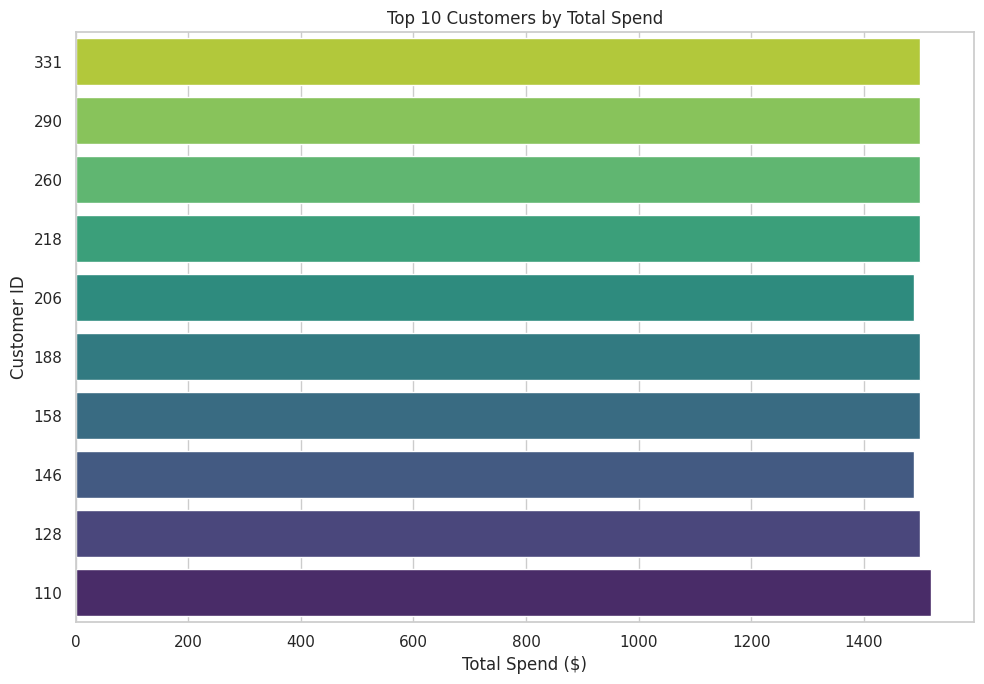

In [55]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Total Spend', y='Customer ID', data=top_customers.head(10), palette='viridis', orient='h')
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Total Spend ($)')
plt.ylabel('Customer ID')
plt.gca().invert_yaxis() # Invert y-axis to have the highest spender at the top
plt.tight_layout()
plt.show()

# **4. FINAL BUSINESS ANALYSIS**

In [43]:
# ============================================================
# PART 10 — FINAL BUSINESS ANALYSIS & EXECUTIVE INSIGHTS
# ============================================================

print("=" * 75)
print("FINAL BUSINESS ANALYSIS & EXECUTIVE INSIGHTS")
print("=" * 75)


# ============================================================
# 1. OVERALL CUSTOMER METRICS
# ============================================================

print("\n1. OVERALL CUSTOMER METRICS")
print("-" * 55)

total_customers = len(df)

total_spend = df['Total Spend'].sum()
average_spend = df['Total Spend'].mean()

average_items = df['Items Purchased'].mean()
average_rating = df['Average Rating'].mean()
average_recency = df['Days Since Last Purchase'].mean()

print(f"Total Customers: {total_customers}")
print(f"Total Customer Spend: ${total_spend:,.2f}")
print(f"Average Customer Spend: ${average_spend:,.2f}")
print(f"Average Items Purchased: {average_items:.2f}")
print(f"Average Customer Rating: {average_rating:.2f}")
print(f"Average Days Since Last Purchase: {average_recency:.2f}")


# ============================================================
# 2. CITY PERFORMANCE
# ============================================================

city_summary = (
    df.groupby('City')
    .agg(
        Customers=('Customer ID', 'count'),
        Total_Spend=('Total Spend', 'sum'),
        Average_Spend=('Total Spend', 'mean'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .sort_values('Total_Spend', ascending=False)
    .round(2)
)

print("\n2. CITY PERFORMANCE")
print("-" * 55)
print(city_summary)


top_city = city_summary['Total_Spend'].idxmax()

print(
    f"\nHighest total-spending city: "
    f"{top_city} "
    f"(${city_summary.loc[top_city, 'Total_Spend']:,.2f})"
)


# ============================================================
# 3. MEMBERSHIP PERFORMANCE
# ============================================================

membership_summary = (
    df.groupby('Membership Type')
    .agg(
        Customers=('Customer ID', 'count'),
        Total_Spend=('Total Spend', 'sum'),
        Average_Spend=('Total Spend', 'mean'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .sort_values('Average_Spend', ascending=False)
    .round(2)
)

print("\n3. MEMBERSHIP PERFORMANCE")
print("-" * 55)
print(membership_summary)


top_membership = membership_summary['Average_Spend'].idxmax()

print(
    f"\nHighest average spending membership: "
    f"{top_membership} "
    f"(${membership_summary.loc[top_membership, 'Average_Spend']:.2f})"
)


# ============================================================
# 4. DISCOUNT PERFORMANCE
# ============================================================

discount_summary = (
    df.groupby('Discount Applied')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Spend=('Total Spend', 'mean'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .round(2)
)

print("\n4. DISCOUNT PERFORMANCE")
print("-" * 55)
print(discount_summary)


# ============================================================
# 5. SATISFACTION PERFORMANCE
# ============================================================

satisfaction_summary = (
    df.groupby('Satisfaction Level')
    .agg(
        Customers=('Customer ID', 'count'),
        Average_Spend=('Total Spend', 'mean'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean'),
        Average_Recency=('Days Since Last Purchase', 'mean')
    )
    .round(2)
)

print("\n5. SATISFACTION PERFORMANCE")
print("-" * 55)
print(satisfaction_summary)


# ============================================================
# 6. CUSTOMER SEGMENT PERFORMANCE
# ============================================================

if 'segment_df' in globals():

    segment_summary = (
        segment_df
        .groupby('Customer Segment')
        .agg(
            Customers=('Customer ID', 'count'),
            Average_Spend=('Total Spend', 'mean'),
            Average_Items=('Items Purchased', 'mean'),
            Average_Recency=('Days Since Last Purchase', 'mean'),
            Average_Rating=('Average Rating', 'mean')
        )
        .round(2)
    )

    print("\n6. CUSTOMER SEGMENT PERFORMANCE")
    print("-" * 55)
    print(segment_summary)

    highest_segment = (
        segment_summary['Average_Spend']
        .idxmax()
    )

    print(
        f"\nHighest average-value segment: "
        f"{highest_segment}"
    )


# ============================================================
# 7. GENDER PERFORMANCE
# ============================================================

gender_summary = (
    df.groupby('Gender')
    .agg(
        Customers=('Customer ID', 'count'),
        Total_Spend=('Total Spend', 'sum'),
        Average_Spend=('Total Spend', 'mean'),
        Average_Items=('Items Purchased', 'mean'),
        Average_Rating=('Average Rating', 'mean')
    )
    .round(2)
)

print("\n7. GENDER PERFORMANCE")
print("-" * 55)
print(gender_summary)


# ============================================================
# 8. CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Days Since Last Purchase'
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
    .round(3)
)

print("\n8. CORRELATION MATRIX")
print("-" * 55)
print(correlation_matrix)


# Find correlations with Total Spend
spend_correlations = (
    correlation_matrix['Total Spend']
    .drop('Total Spend')
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("\nVariables most associated with Total Spend:")
print(spend_correlations)


# ============================================================
# 9. TOP 10 CUSTOMERS BY SPENDING
# ============================================================

print("\n9. TOP 10 CUSTOMERS BY TOTAL SPEND")
print("-" * 55)

top_customers = (
    df[
        [
            'Customer ID',
            'City',
            'Membership Type',
            'Total Spend',
            'Items Purchased',
            'Average Rating',
            'Days Since Last Purchase',
            'Satisfaction Level'
        ]
    ]
    .sort_values(
        'Total Spend',
        ascending=False
    )
    .head(10)
)

print(top_customers.to_string(index=False))


# ============================================================
# 10. HIGH-VALUE ACTIVE CUSTOMERS
# ============================================================

high_value_active = df[
    (df['Total Spend'] >= df['Total Spend'].quantile(0.75)) &
    (df['Items Purchased'] >= df['Items Purchased'].quantile(0.75)) &
    (df['Days Since Last Purchase'] <= df['Days Since Last Purchase'].quantile(0.25))
]

print("\n10. HIGH-VALUE ACTIVE CUSTOMER PROFILE")
print("-" * 55)

print(
    f"Customers meeting high-value active criteria: "
    f"{len(high_value_active)}"
)

print(
    f"Average Spend: "
    f"${high_value_active['Total Spend'].mean():.2f}"
)

print(
    f"Average Items: "
    f"{high_value_active['Items Purchased'].mean():.2f}"
)

print(
    f"Average Recency: "
    f"{high_value_active['Days Since Last Purchase'].mean():.2f} days"
)

print(
    f"Average Rating: "
    f"{high_value_active['Average Rating'].mean():.2f}"
)


# ============================================================
# 11. LESS ACTIVE CUSTOMERS
# ============================================================

less_active = df[
    df['Days Since Last Purchase'] >=
    df['Days Since Last Purchase'].quantile(0.75)
]

print("\n11. LESS ACTIVE CUSTOMER PROFILE")
print("-" * 55)

print(
    f"Customers in less-active group: "
    f"{len(less_active)}"
)

print(
    f"Average Spend: "
    f"${less_active['Total Spend'].mean():.2f}"
)

print(
    f"Average Items: "
    f"{less_active['Items Purchased'].mean():.2f}"
)

print(
    f"Average Days Since Last Purchase: "
    f"{less_active['Days Since Last Purchase'].mean():.2f}"
)

print(
    f"Average Rating: "
    f"{less_active['Average Rating'].mean():.2f}"
)


# ============================================================
# 12. IMPORTANT STRUCTURAL RELATIONSHIPS
# ============================================================

print("\n12. STRUCTURAL DATA PATTERNS")
print("-" * 55)

city_discount = pd.crosstab(
    df['City'],
    df['Discount Applied'],
    normalize='index'
).mul(100).round(2)

print("\nDiscount distribution by city (%):")
print(city_discount)

membership_satisfaction = pd.crosstab(
    df['Membership Type'],
    df['Satisfaction Level'],
    normalize='index'
).mul(100).round(2)

print("\nSatisfaction distribution by membership (%):")
print(membership_satisfaction)


# ============================================================
# 13. FINAL BUSINESS INSIGHTS
# ============================================================

print("\n13. FINAL BUSINESS INSIGHTS")
print("-" * 55)

print(
    f"1. {top_city} has the highest total customer spending "
    f"in the dataset."
)

print(
    f"2. {top_membership} customers have the highest "
    f"average spending among membership groups."
)

print(
    "3. High-value active customers combine relatively high "
    "spending and purchase volume with more recent activity."
)

print(
    "4. Satisfaction level is strongly associated with "
    "spending, purchase volume, rating and recency."
)

print(
    "5. Items Purchased has a very strong positive association "
    "with Total Spend."
)

print(
    "6. Days Since Last Purchase has a negative association "
    "with Total Spend."
)

print(
    "7. The dataset contains highly structured relationships "
    "between City, Discount, Membership and Satisfaction."
)

print(
    "8. These relationships should be interpreted as "
    "descriptive associations rather than causal effects."
)


# ============================================================
# 14. BUSINESS RECOMMENDATIONS
# ============================================================

print("\n14. BUSINESS RECOMMENDATIONS")
print("-" * 55)

print(
    "1. Monitor high-value active customers and maintain "
    "engagement through relevant retention strategies."
)

print(
    "2. Investigate less-active customers using their recency "
    "and spending behavior to identify potential re-engagement opportunities."
)

print(
    "3. Examine the relationship between membership benefits "
    "and customer spending/satisfaction using additional real-world data."
)

print(
    "4. Evaluate discount strategies by comparing customer "
    "segments while controlling for city and membership."
)

print(
    "5. Collect additional transaction-level and time-based "
    "data to perform stronger behavioral and causal analysis."
)


print("\n" + "=" * 75)
print("FINAL BUSINESS ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 75)

FINAL BUSINESS ANALYSIS & EXECUTIVE INSIGHTS

1. OVERALL CUSTOMER METRICS
-------------------------------------------------------
Total Customers: 350
Total Customer Spend: $295,883.60
Average Customer Spend: $845.38
Average Items Purchased: 12.60
Average Customer Rating: 4.02
Average Days Since Last Purchase: 26.59

2. CITY PERFORMANCE
-------------------------------------------------------
               Customers  Total_Spend  Average_Spend  Average_Items  \
City                                                                  
San Francisco         58      84666.8        1459.77          20.00   
New York              59      68737.1        1165.04          15.27   
Los Angeles           59      47524.0         805.49          11.68   
Miami                 58      40042.6         690.39          11.64   
Chicago               58      28993.2         499.88           9.41   
Houston               58      25919.9         446.89           7.57   

               Average_Rating  Avera